In [28]:
import numpy as np 
import wandb
import os
import pandas as pd
import plotly.express as px
from matplotlib import pyplot as plt
from plotly import graph_objects as go



PLOTS_DIR = "./plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

TABLES_DIR = "./tables"
os.makedirs(TABLES_DIR, exist_ok=True)


INCH_OVER_CM = 2.54
PAGE_WIDTH = 14.8 / INCH_OVER_CM
PAGE_HEIGHT = 24.5 / INCH_OVER_CM


plt.rcParams.update({
    "font.size": 10,          # default text
    "axes.titlesize": 12,     # figure title
    "axes.labelsize": 10,     # x and y labels
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

plt.rcParams.update({
    "text.usetex": True,              # use LaTeX for all text
    "font.family": "serif",           # LaTeX serif font (Computer Modern by default)
    "axes.unicode_minus": False,      # ensure minus signs render correctly
})


%config InlineBackend.figure_format = 'retina'   # high quality
plt.rcParams["figure.dpi"] = 150


def save_figure(fig: plt.Figure, filename: str): 
    fig.savefig(os.path.join(PLOTS_DIR, filename), transparent=True, bbox_inches="tight")

# Generic plotting 

In [29]:
def plot_metric_boxplot(
    df: pd.DataFrame, 
    metric: str, 
    group_col: str,
    xlim: tuple = None, 
    xlabel: str = None, 
    width: float = PAGE_WIDTH / 2, 
    height: float = PAGE_WIDTH / 2 * 0.4,
    flier_size: float = 3,
):
    """
    Create a horizontal boxplot of a metric grouped by a column.
    
    Args:
        df (pd.DataFrame): DataFrame containing data.
        metric (str): Column name with numeric values to plot.
        group_col (str): Column name to group runs (each box = one group).
        xlim (tuple, optional): (xmin, xmax) limits for x-axis.
        xlabel (str, optional): Label for x-axis.
    """
    # props 
    flierprops = dict(marker='o', markersize=flier_size, linestyle='none', markeredgecolor='black')


    # group data
    grouped = [df.loc[df[group_col] == g, metric].dropna().values
               for g in df[group_col].unique()]
    labels = df[group_col].unique()
    
    fig, ax = plt.subplots(figsize=(width, height))
    ax.boxplot(grouped, tick_labels=labels, vert=False, flierprops=flierprops)
    
    # styling
    ax.set_ylabel("")  # no y-label
    if xlabel:
        ax.set_xlabel(xlabel)
    if xlim:
        ax.set_xlim(xlim)
    
    return fig, ax


def plot_epoch_metric(
    df, 
    name_col: str, 
    metric: str,
    xlabel: str = "Epoch", 
    ylabel: str = None,
    width: float = 8, 
    height: float = 5,
    ncol: int | None = None,
):
    """
    Create an epoch vs metric lineplot with shaded error regions, colored by name_col.
    
    Args:
        df (pd.DataFrame): DataFrame with columns [epoch, metric, name_col].
        name_col (str): Column used to group runs (different lines/colors).
        metric (str): Column with metric values to plot.
        xlabel (str, optional): X-axis label. Default = "Epoch".
        ylabel (str, optional): Y-axis label. Default = None.
        width (float, optional): Figure width. Default = 8.
        height (float, optional): Figure height. Default = 5.
    
    Returns:
        fig, ax: Matplotlib Figure and Axes objects.
    """
    fig, ax = plt.subplots(figsize=(width, height))

    # group by name and epoch → compute mean & std
    grouped = df.groupby([name_col, "epoch"])[metric]
    stats = grouped.agg(["mean", "std"]).reset_index()

    # plot each group
    for name, g in stats.groupby(name_col):
        ax.plot(g["epoch"], g["mean"], label=name, linewidth=1)
        ax.fill_between(g["epoch"],
                        g["mean"] - 2 * g["std"],
                        g["mean"] + 2 * g["std"],
                        alpha=0.2)

    # labels
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    # legend above plot, horizontal, no title
    ncol = ncol or len(stats[name_col].unique())
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25 + 0.1 * 1/ncol),
              ncol=ncol, frameon=False, title=None)

    return fig, ax


In [30]:
sde_to_name = {
    'topological': 'Topological',
    'euclidean': 'Euclidean',
}

coupling_to_name = {
    'online_ot': 'Online OT',
    'ot': 'OT',
    'independent': 'Independent',
}


sde_to_abbrev = {
    'topological': 'Top',
    'euclidean': 'Euc',
}

coupling_to_abbrev = {
    'online_ot': 'OnOT',
    'ot': 'OT',
    'independent': 'ID',
}


def add_name(df: pd.DataFrame):
    df['name'] = df['sde'].map(sde_to_name) + ' + ' + df['coupling'].map(coupling_to_name)
    df['abbrev'] = df['sde'].map(sde_to_abbrev) + '+' + df['coupling'].map(coupling_to_abbrev)
    return df

# Earthquake experiment

In [49]:
from datetime import datetime, timezone


def get_runs_with_tags_after_date(entity: str, project: str, tags: list, after_date: datetime, before_date: datetime = None):
    """
    Retrieve runs from W&B with given tags and created after a specific date.
    
    Args:
        entity (str): W&B entity (user or team).
        project (str): W&B project name.
        tags (list): List of tags to filter on.
        after_date (datetime): Only return runs created after this datetime (UTC).
    
    Returns:
        list: List of wandb.apis.public.Run objects.
    """
    api = wandb.Api()

    if isinstance(after_date, datetime):
        if after_date.tzinfo is None:
            after_date = after_date.replace(tzinfo=timezone.utc)
        after_date = after_date.isoformat()

    if before_date is not None and isinstance(before_date, datetime):
        if before_date.tzinfo is None:
            before_date = before_date.replace(tzinfo=timezone.utc)
        before_date = before_date.isoformat()


    if before_date is not None:
        filters = {
            "created_at": {"$gte": after_date, "$lte": before_date},
        }
    else:
        filters = {
            "created_at": {"$gte": after_date},
        }
    filters["tags"] = {"$all": tags}
    filters["state"] = "finished"
    project_path = f"{entity}/{project}"
    project_path = f"{entity}/{project}"
    runs = api.runs(project_path, filters=filters)
    return runs


def runs_to_metrics_df(runs, metrics: list):
    """
    Convert runs into a DataFrame with one row per run and selected metrics.
    
    Args:
        runs (list): List of wandb.apis.public.Run objects.
        metrics (list): Metric names to extract from run.summary.
    
    Returns:
        pd.DataFrame: DataFrame with run metadata and requested metrics.
    """
    rows = []
    for run in runs:
        row = {
            "coupling": run.config['train']['coupling']['name'],
            "dataset": run.config['data']['name'],
            "sde": run.config['sde']['name'].split('_')[0],
            "date": run.created_at,
            "seed": run.config['run']['seed'],
        }
        # Add requested metrics from summary (final values)
        for m in metrics:
            row[m] = run.summary.get(m, None)
        rows.append(row)
    
    df = pd.DataFrame(rows)
    df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)
    return df


def runs_to_training_history(runs, val_metrics: list,
                             train_metric: str = "train/loss",
                             epoch_col: str = "epoch"):
    """
    Collect training loss and multiple validation metric histories from runs into one DataFrame.
    
    Args:
        runs (list): List of wandb.apis.public.Run objects.
        val_metrics (list): List of validation metric names to fetch (as logged in wandb).
        train_metric (str, optional): Training metric name. Default = "train/loss".
        epoch_col (str, optional): Epoch column name. Default = "epoch".
    
    Returns:
        pd.DataFrame: Long-form DataFrame with columns:
                      [run_id, run_name, epoch, train_metric, *val_metrics]
    """
    history_dfs = []
    keys = [epoch_col, train_metric] + val_metrics
    
    for run in runs:
        # summary
        row = {
            "coupling": run.config['train']['coupling']['name'],
            "dataset": run.config['data']['name'],
            "sde": run.config['sde']['name'].split('_')[0],
            "date": run.created_at,
            "seed": run.config['run']['seed'],
        }

        # history
        hist = run.history(keys=keys).drop('_step', axis=1)

        # Add summary to history
        for k, v in row.items():
            hist[k] = v

        history_dfs.append(hist)
    
    df = pd.concat(history_dfs, ignore_index=True)    
    df = df.groupby(['dataset', 'sde', 'coupling', 'epoch']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)
    return df

# Experiment: Earthquake Magnitudes

Fetching runs...
Loading test data...


/tmp/ipykernel_252297/1033456339.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


Plotting test data...
Loading training data...


/tmp/ipykernel_252297/1033456339.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling', 'epoch']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


Plotting training data...
Done!


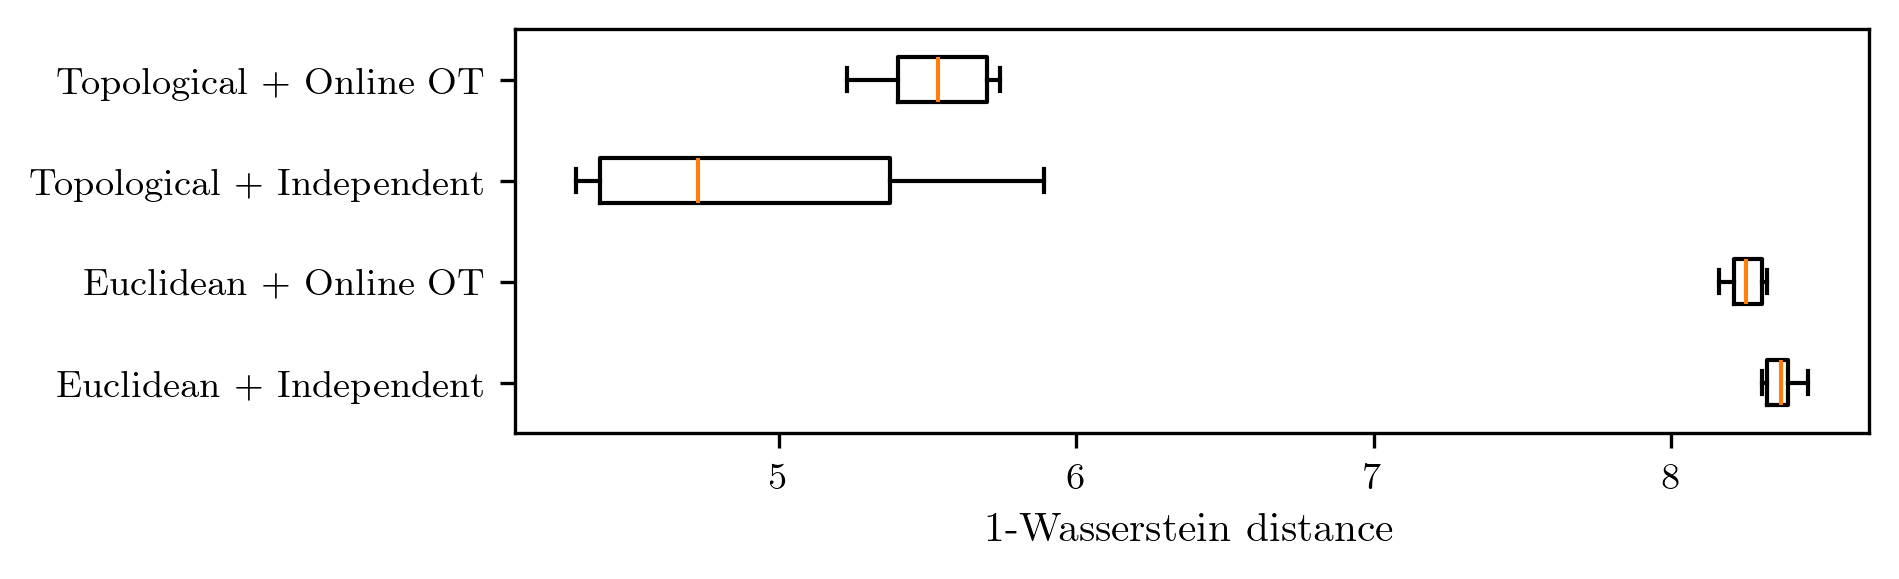

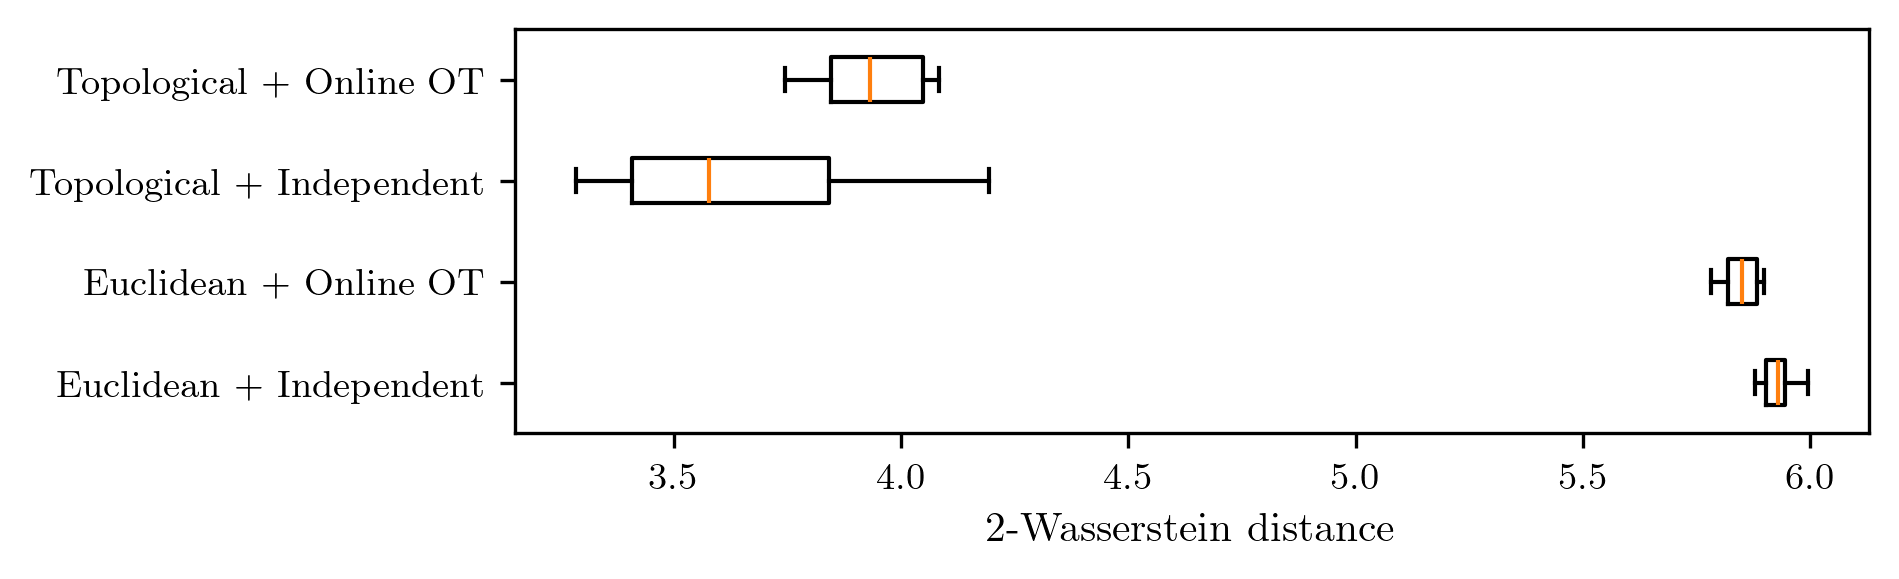

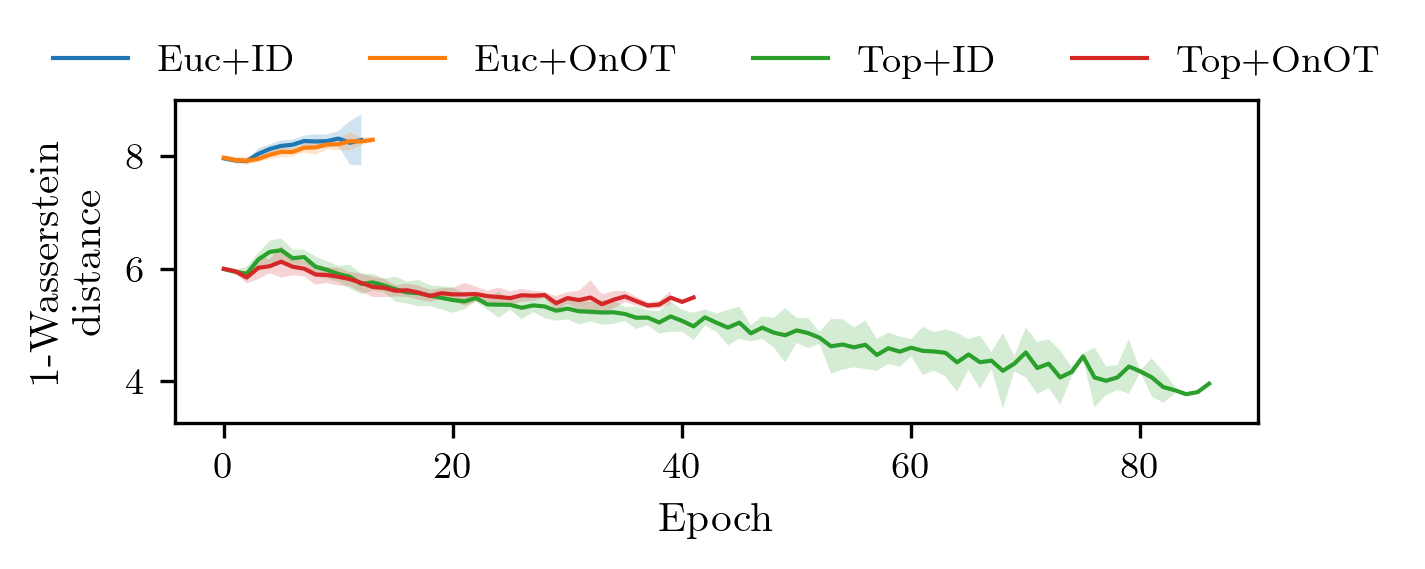

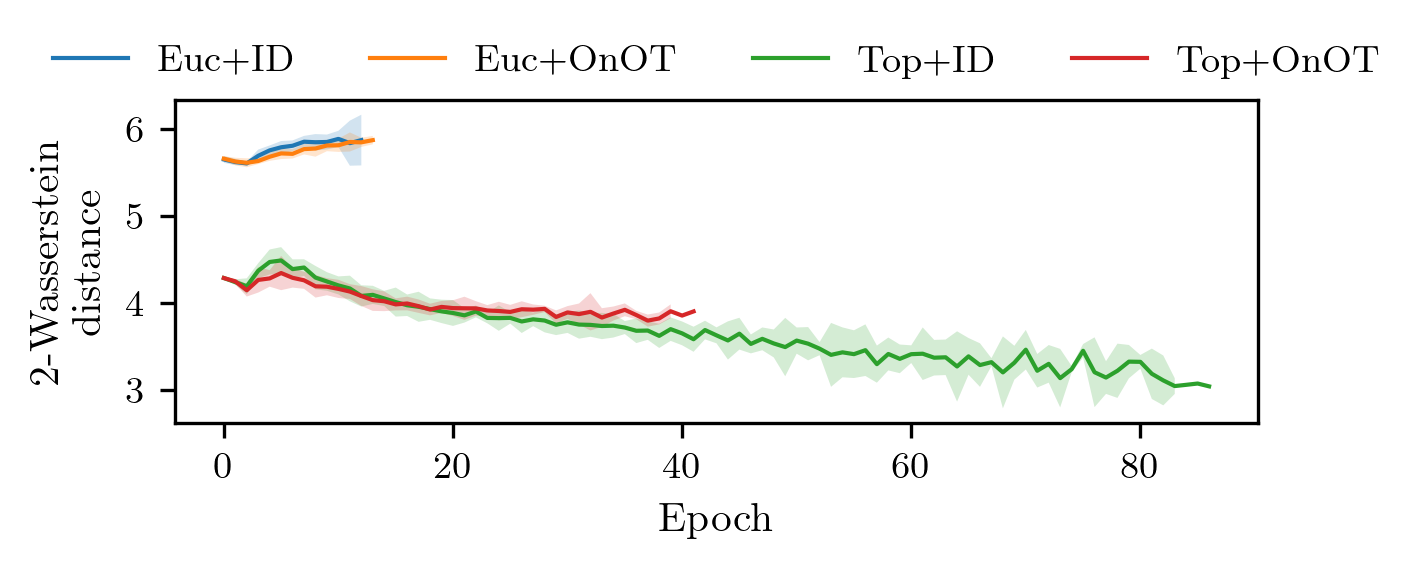

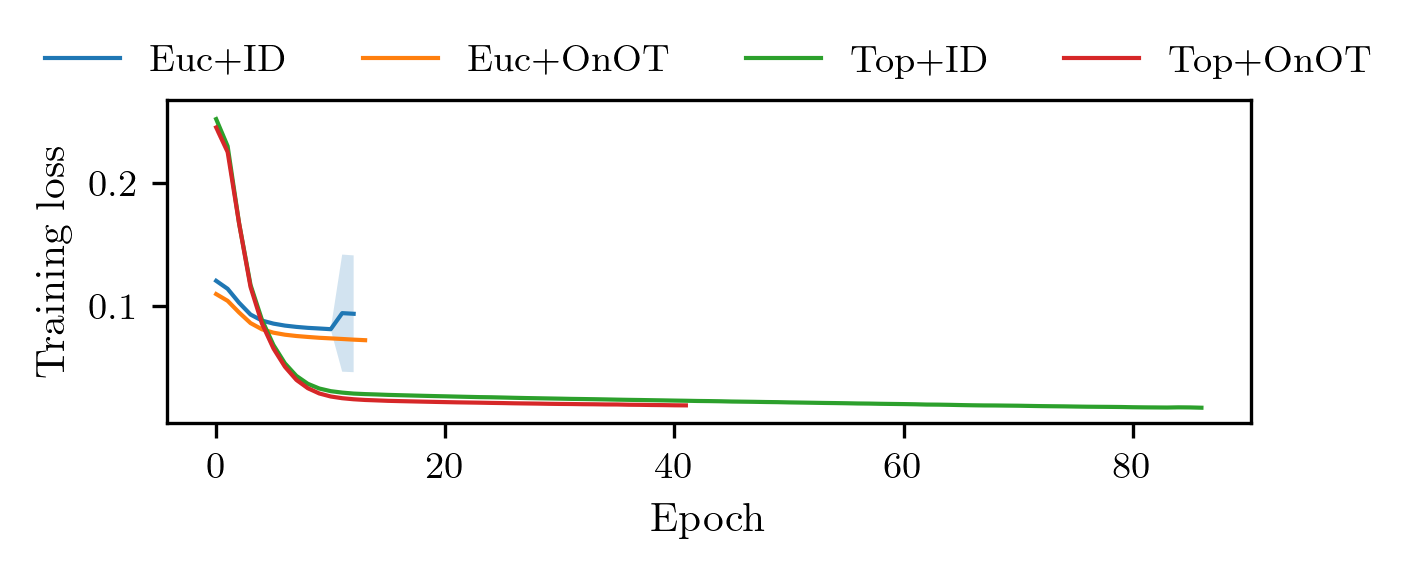

In [57]:
############################################## Fetch runs ##############################################
print("Fetching runs...")
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
experiment_name='earthquakes'
tags=[experiment_name]
date = datetime(year=2025, month=9, day=2)
before_date = datetime(year=2025, month=9, day=10)
runs = get_runs_with_tags_after_date(entity, project, tags, date, before_date)


############################################## TEST DATA ##############################################
# Load test data
print("Loading test data...")
test_metrics = [
    'test/W1', 
    'test/W2',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)
df.head()


# Plot
print("Plotting test data...")
width = PAGE_WIDTH
height = width * 0.3

fig, ax = plot_metric_boxplot(
    df, 
    'test/W1', 
    'name', 
    xlabel='1-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w1.pdf")


fig, ax = plot_metric_boxplot(
    df, 
    'test/W2', 
    'name', 
    xlabel='2-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w2.pdf")



############################################## TRAINING DATA ##############################################
# Load data
print("Loading training data...")
epoch_col = "epoch"
train_metric = "train/loss"
val_metrics = ['val/W1', 'val/W2']
df = runs_to_training_history(runs, val_metrics, train_metric, epoch_col)
add_name(df)


# Plot
print("Plotting training data...")
width = PAGE_WIDTH * 0.8
height = width * 0.3

fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W1", 
    width=width, 
    height=height,
    xlabel="Epoch",
    ylabel="1-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w1.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W2", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="2-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w2.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "train/loss", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="Training loss",
)
save_figure(fig, f"{experiment_name}-train_loss.pdf")


print("Done!")

In [56]:
df.query('epoch > 100')

,epoch,train/loss,val/W1,val/W2,coupling,dataset,sde,date,seed,name,abbrev
237,102,0.059656,6.802067,4.919576,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
238,107,0.058982,6.485607,4.692172,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
239,110,0.058909,6.648932,4.824196,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
240,111,0.058649,6.499491,4.728549,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
241,115,0.058850,6.200375,4.493322,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
...,...,...,...,...,...,...,...,...,...,...,...
683,992,0.043255,5.736055,4.328126,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
684,993,0.042867,5.677118,4.282096,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
685,994,0.042942,5.833394,4.419834,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID
686,997,0.043051,6.140173,4.635155,independent,earthquakes,euclidean,2025-09-01T16:11:30Z,0,Euclidean + Independent,Euc+ID


# Experiment: Brain

Fetching runs...
Loading test data...


/tmp/ipykernel_252297/3778568983.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


Plotting test data...
Loading training data...


/tmp/ipykernel_252297/3778568983.py:102: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling', 'epoch']).apply(lambda x: x.drop_duplicates(subset=['seed'])).reset_index(drop=True)


Plotting training data...
Done!


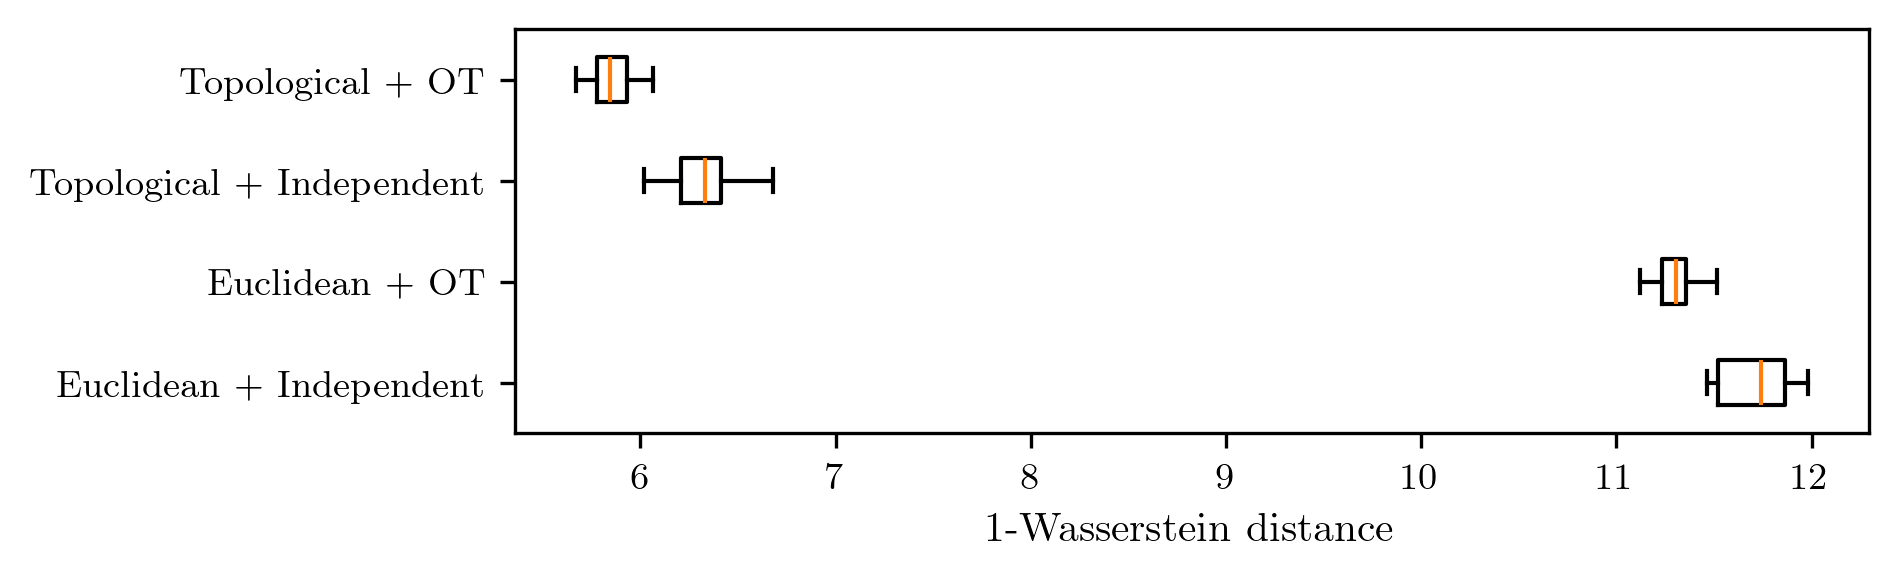

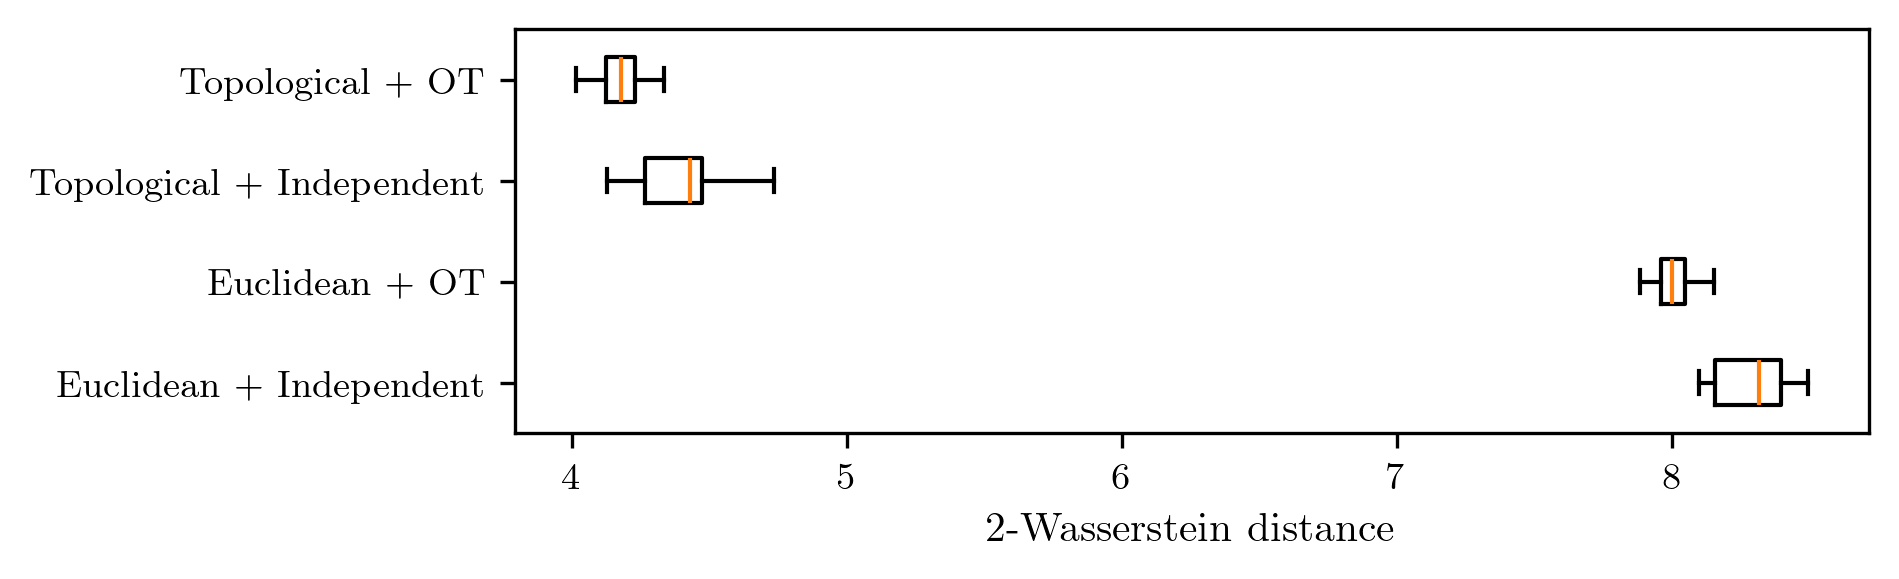

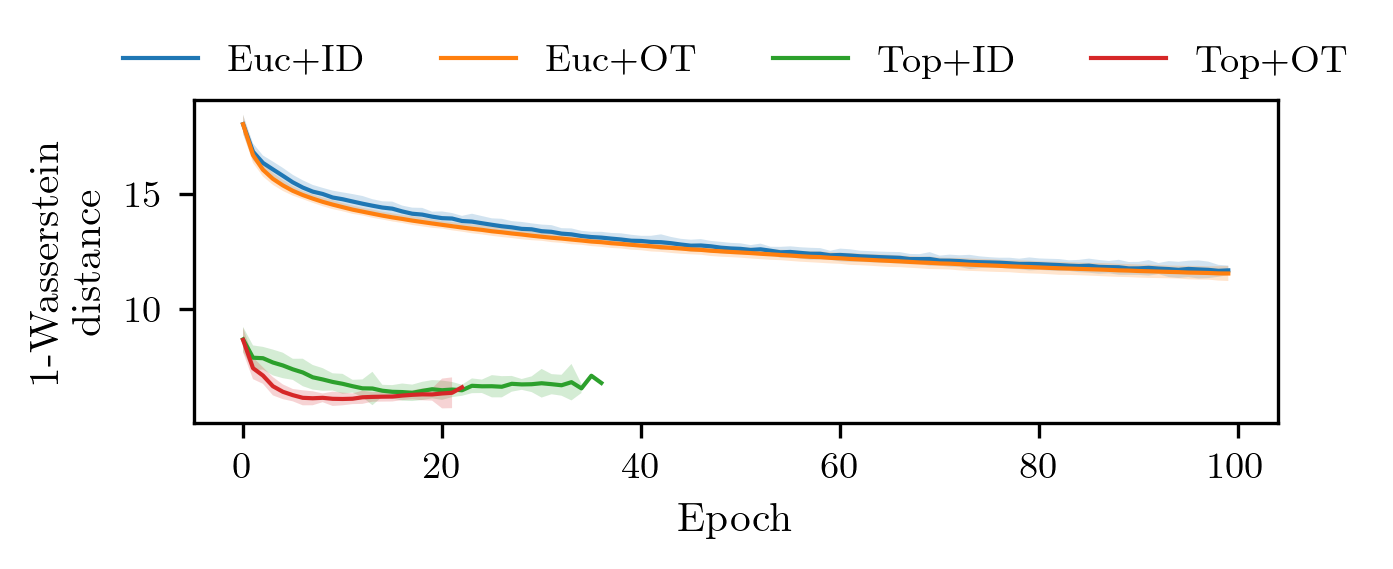

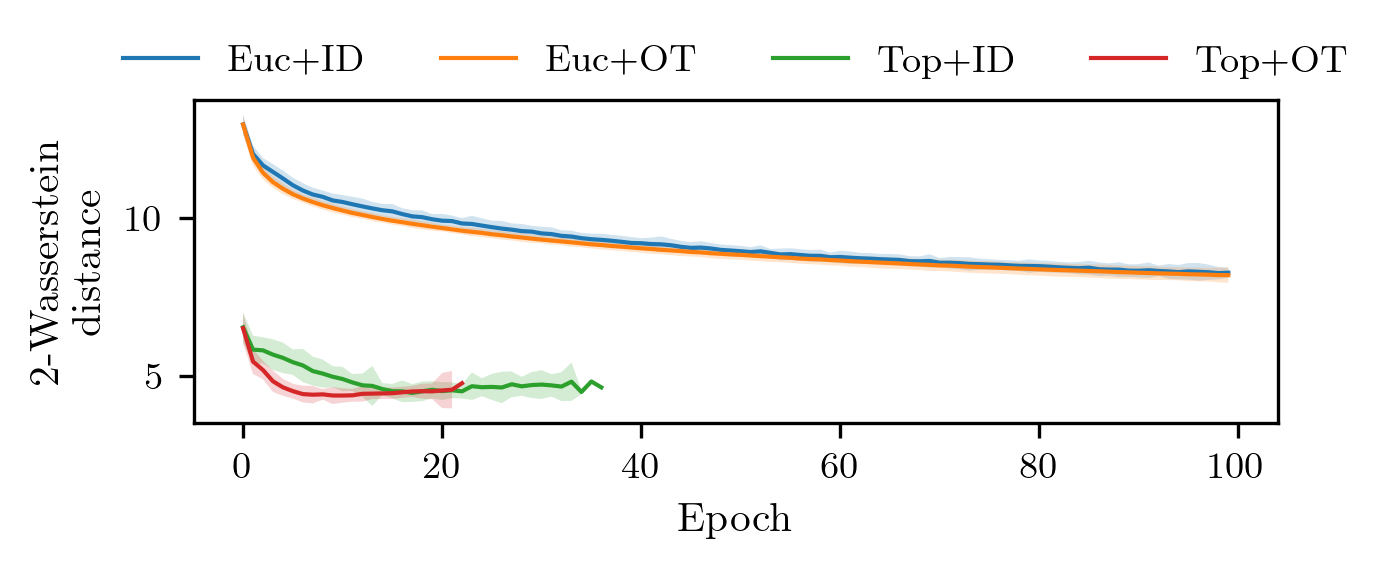

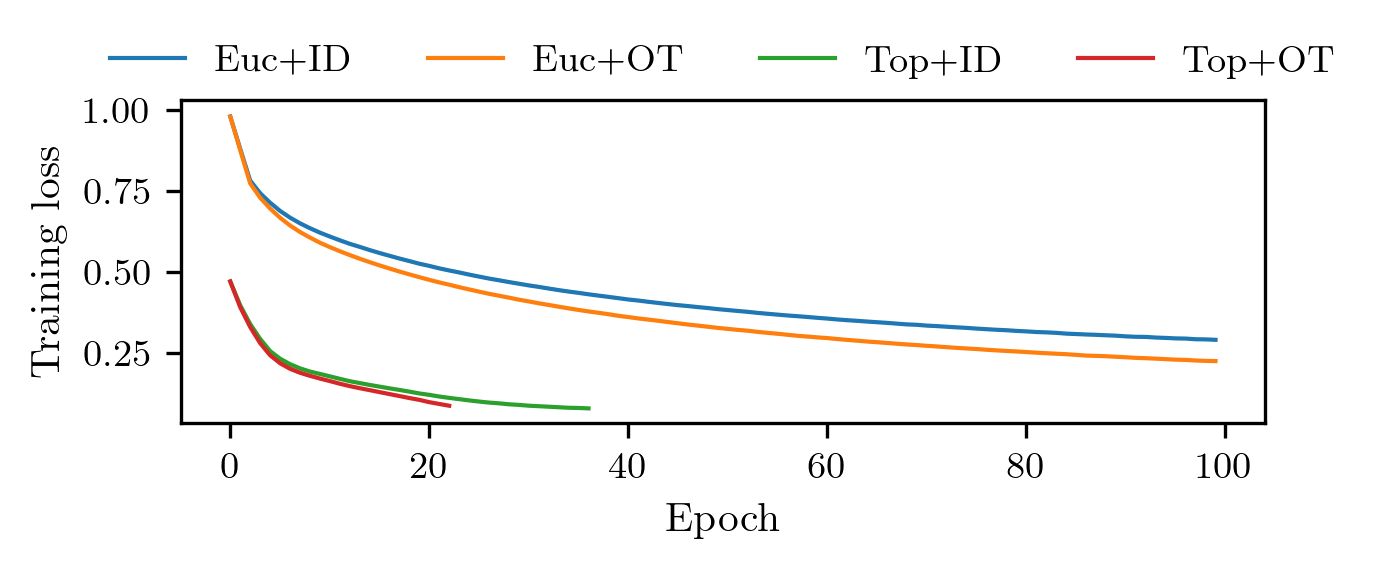

In [33]:
############################################## Fetch runs ##############################################
print("Fetching runs...")
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
experiment_name='brain'
tags=[experiment_name]
date = datetime(year=2025, month=8, day=30)
runs = get_runs_with_tags_after_date(entity, project, tags, date)


############################################## TEST DATA ##############################################
# Load test data
print("Loading test data...")
test_metrics = [
    'test/W1', 
    'test/W2',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)
df.head()


# Plot
print("Plotting test data...")
width = PAGE_WIDTH
height = width * 0.3

fig, ax = plot_metric_boxplot(
    df, 
    'test/W1', 
    'name', 
    xlabel='1-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w1.pdf")


fig, ax = plot_metric_boxplot(
    df, 
    'test/W2', 
    'name', 
    xlabel='2-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w2.pdf")



############################################## TRAINING DATA ##############################################
# Load data
print("Loading training data...")
epoch_col = "epoch"
train_metric = "train/loss"
val_metrics = ['val/W1', 'val/W2']
df = runs_to_training_history(runs, val_metrics, train_metric, epoch_col)
add_name(df)


# Plot
print("Plotting training data...")
width = PAGE_WIDTH * 0.8
height = width * 0.3

fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W1", 
    width=width, 
    height=height,
    xlabel="Epoch",
    ylabel="1-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w1.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W2", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="2-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w2.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "train/loss", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="Training loss",
)
save_figure(fig, f"{experiment_name}-train_loss.pdf")


print("Done!")

In [44]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def make_latex_table(df, model_col: str, coupling_col: str,
                     dataset_col: str, metric: str, digits: int = 3):
    """
    Create a LaTeX-ready table with datasets as columns,
    hierarchical index (model → coupling) as rows,
    showing mean ± std of a metric, bolding the lowest mean in each column.

    Args:
        df (pd.DataFrame): Input dataframe with model, coupling, dataset, and metric columns.
        model_col (str): Column name for models (outer row index).
        coupling_col (str): Column name for coupling (inner row index).
        dataset_col (str): Column name for datasets (columns).
        metric (str): Column name for the metric to summarize.
        digits (int): Number of decimal places for formatting.

    Returns:
        pd.DataFrame: Formatted table (strings) ready for .to_latex(escape=False).
    """
    # aggregate mean and std
    agg = (
        df.groupby([model_col, coupling_col, dataset_col])[metric]
          .agg(["mean", "std"])
          .reset_index()
    )

    # build pivot: rows = (model, coupling), columns = dataset
    table = pd.DataFrame(
        index=pd.MultiIndex.from_product(
            [agg[model_col].unique(), agg[coupling_col].unique()],
            names=[model_col, coupling_col]
        ),
        columns=agg[dataset_col].unique()
    )

    # fill in formatted mean ± std
    for _, row in agg.iterrows():
        val = f"{row['mean']:.{digits}f} \(\pm\) {row['std']:.{digits}f}"
        table.loc[(row[model_col], row[coupling_col]), row[dataset_col]] = val

    # bold the lowest mean per dataset
    for dataset in agg[dataset_col].unique():
        # parse mean values
        col_vals = []
        for idx, cell in table[dataset].dropna().items():
            try:
                mu = float(cell.split("±")[0].split()[0])
            except Exception:
                mu = np.inf
            col_vals.append((idx, mu))
        if not col_vals:
            continue
        best_idx, _ = min(col_vals, key=lambda x: x[1])
        table.loc[best_idx, dataset] = (
            r"\textbf{" + table.loc[best_idx, dataset] + r"}"
        )

    return table



def save_table_to_latex(
    table_df: pd.DataFrame,
    name: str | None = None,
    caption: str | None = None,
    label: str | None = None,
    index: bool = True, 
) -> str:
    """
    Convert the formatted table to LaTeX. Use escape=False to preserve math and bold.
    Saves the table to a file with the given name in the tables directory.
    """
    latex_str = table_df.to_latex(
        escape=False,
        index=index,
        caption=caption,
        label=label,
        multicolumn=True,
        multicolumn_format='c',
        bold_rows=True if index else False,
    )

    # Save to file if name is provided
    file_path = os.path.join(TABLES_DIR, name)
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(latex_str)

    return latex_str    

# Experiment: Traffic

Fetching runs...
Loading test data...


/tmp/ipykernel_252297/3342232921.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


Plotting test data...
Loading training data...


/tmp/ipykernel_252297/3342232921.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling', 'epoch']).apply(lambda x: x.drop_duplicates(subset=['seed'])).reset_index(drop=True)


Plotting training data...
Done!


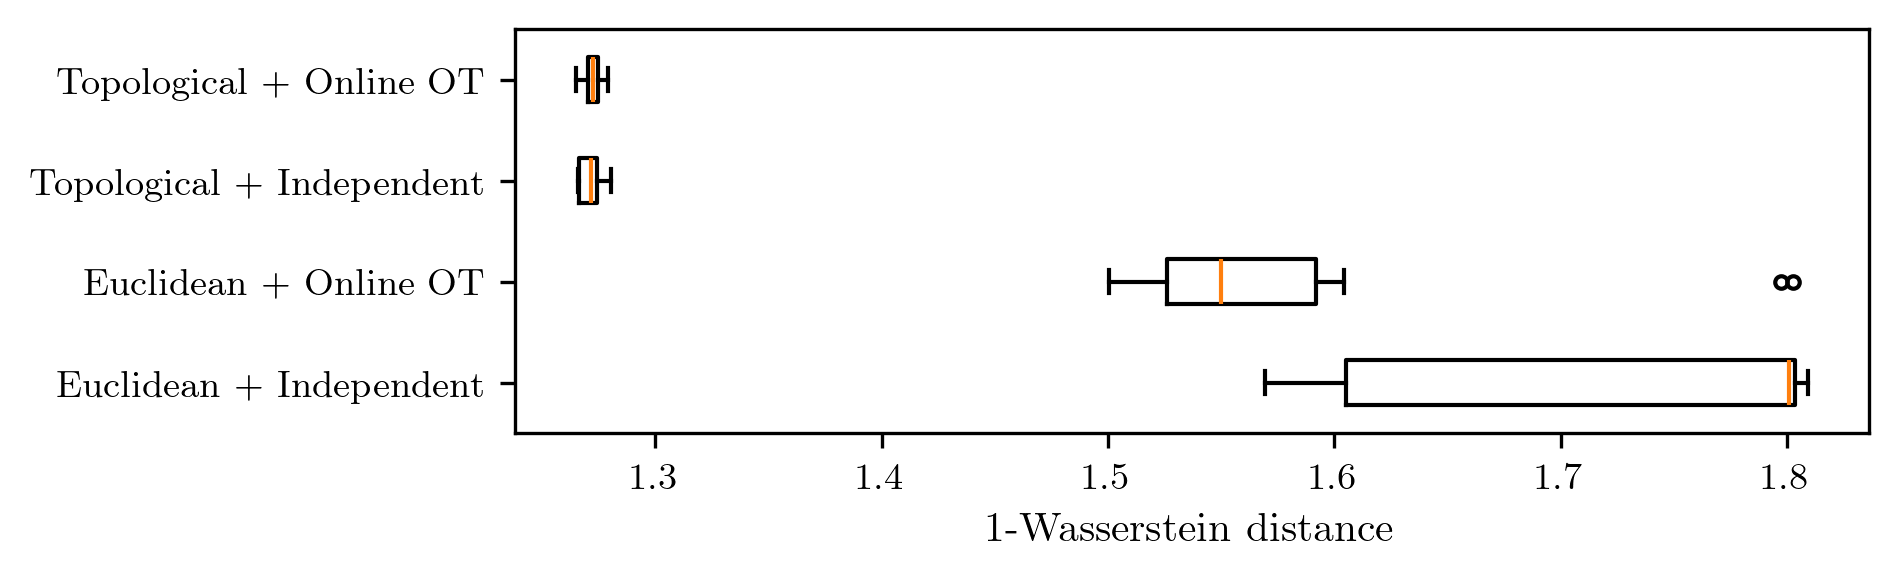

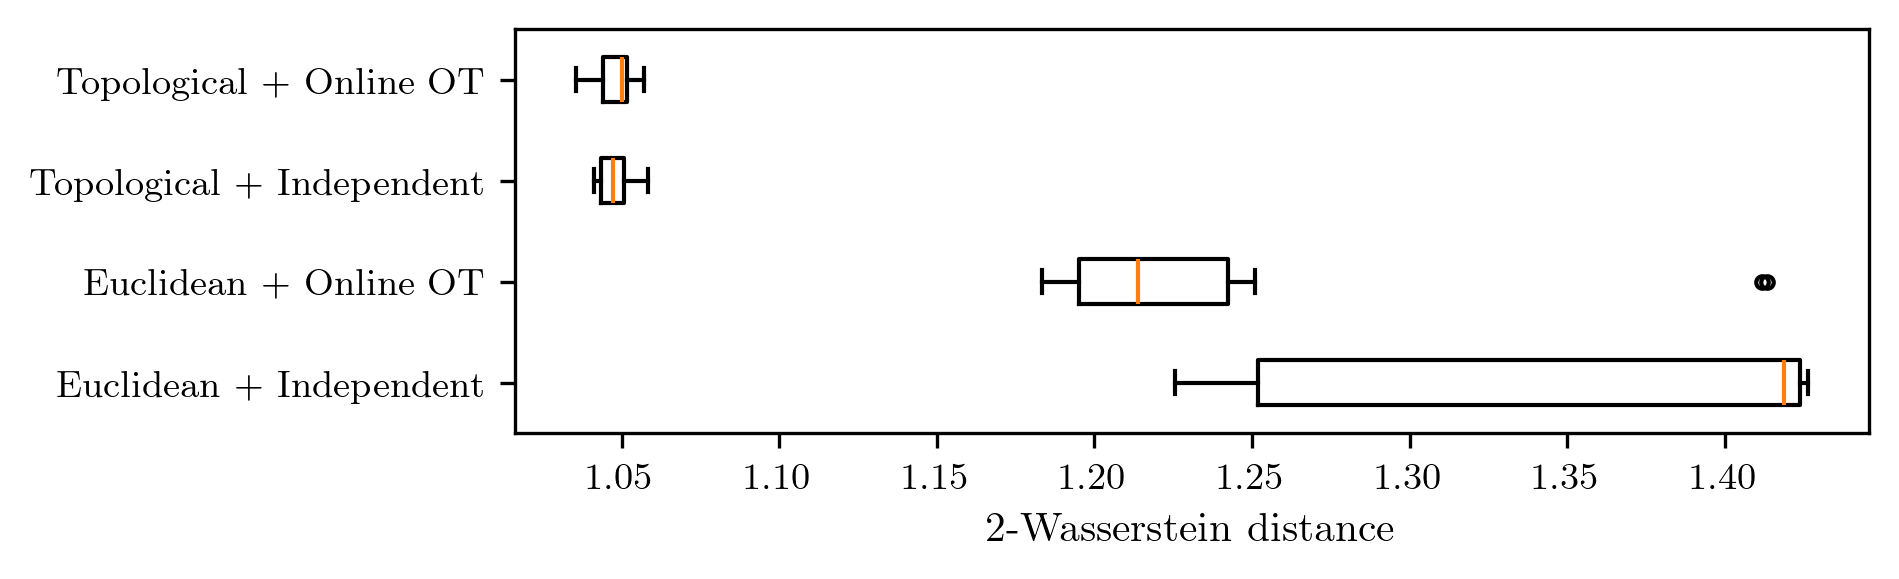

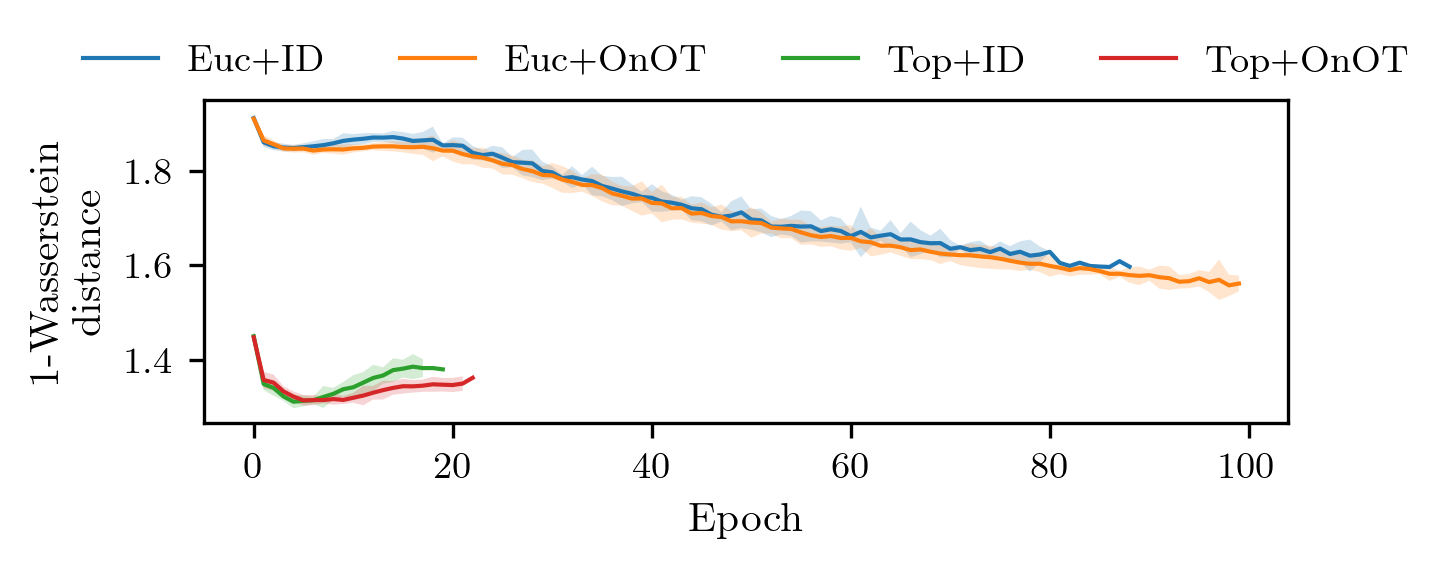

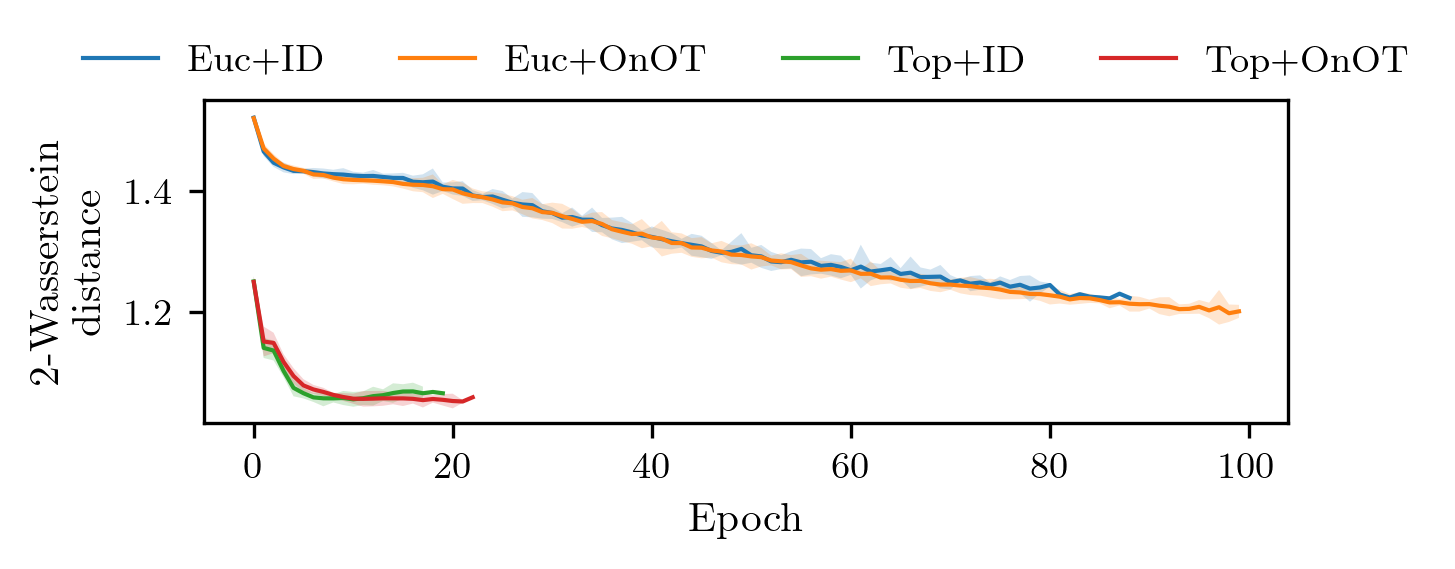

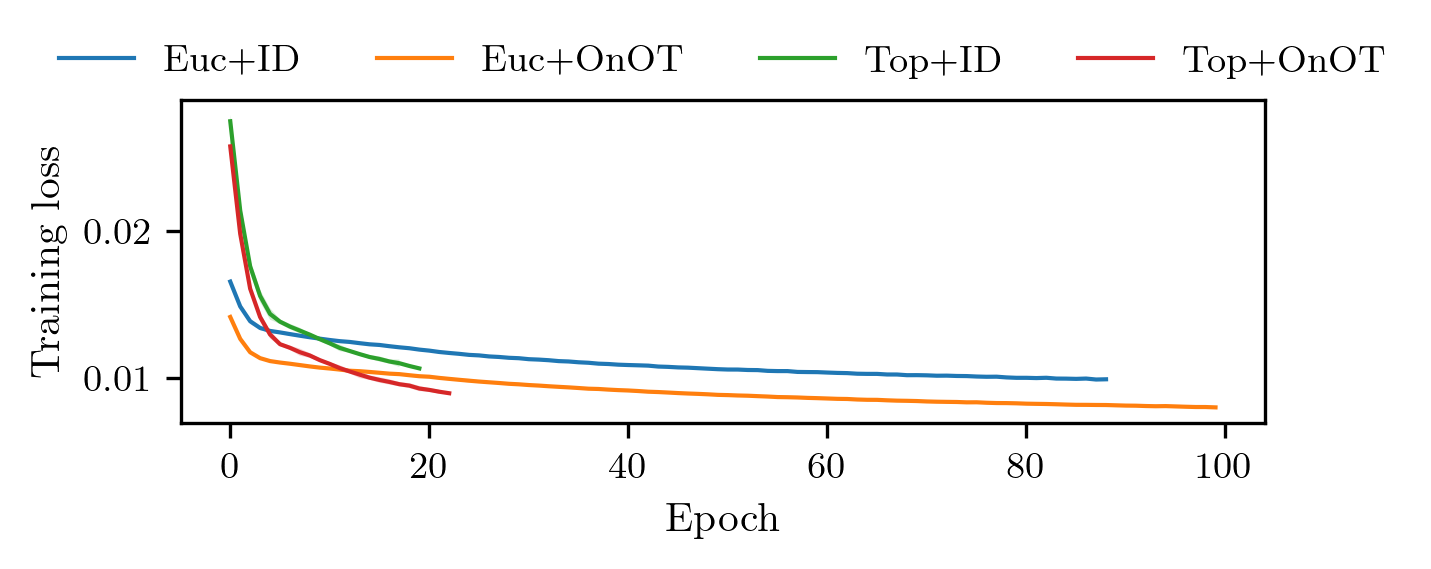

In [48]:
############################################## Fetch runs ##############################################
print("Fetching runs...")
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
experiment_name='traffic'
tags=[experiment_name]
date = datetime(year=2025, month=8, day=30)
before_date = datetime(year=2025, month=9, day=2)
runs = get_runs_with_tags_after_date(entity, project, tags, date, before_date)


############################################## TEST DATA ##############################################
# Load test data
print("Loading test data...")
test_metrics = [
    'test/W1', 
    'test/W2',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)
df.head()


# Plot
print("Plotting test data...")
width = PAGE_WIDTH
height = width * 0.3

fig, ax = plot_metric_boxplot(
    df, 
    'test/W1', 
    'name', 
    xlabel='1-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w1.pdf")


fig, ax = plot_metric_boxplot(
    df, 
    'test/W2', 
    'name', 
    xlabel='2-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w2.pdf")



############################################## TRAINING DATA ##############################################
# Load data
print("Loading training data...")
epoch_col = "epoch"
train_metric = "train/loss"
val_metrics = ['val/W1', 'val/W2']
df = runs_to_training_history(runs, val_metrics, train_metric, epoch_col)
add_name(df)


# Plot
print("Plotting training data...")
width = PAGE_WIDTH * 0.8
height = width * 0.3

fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W1", 
    width=width, 
    height=height,
    xlabel="Epoch",
    ylabel="1-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w1.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W2", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="2-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w2.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "train/loss", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="Training loss",
)
save_figure(fig, f"{experiment_name}-train_loss.pdf")


print("Done!")

# Experiment: Ocean

Fetching runs...
Loading test data...


/tmp/ipykernel_252297/3342232921.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


Plotting test data...
Loading training data...


/tmp/ipykernel_252297/3342232921.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling', 'epoch']).apply(lambda x: x.drop_duplicates(subset=['seed'])).reset_index(drop=True)


Plotting training data...
Done!


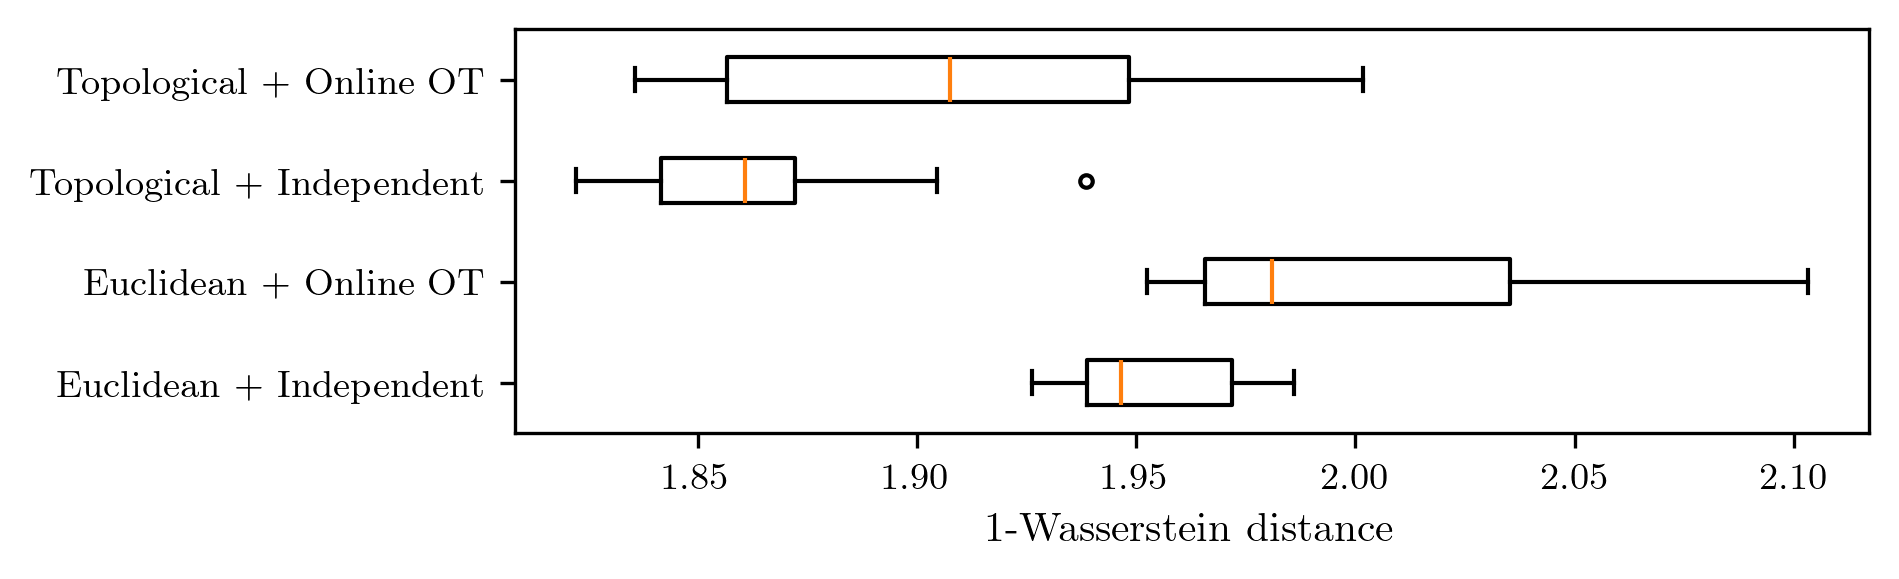

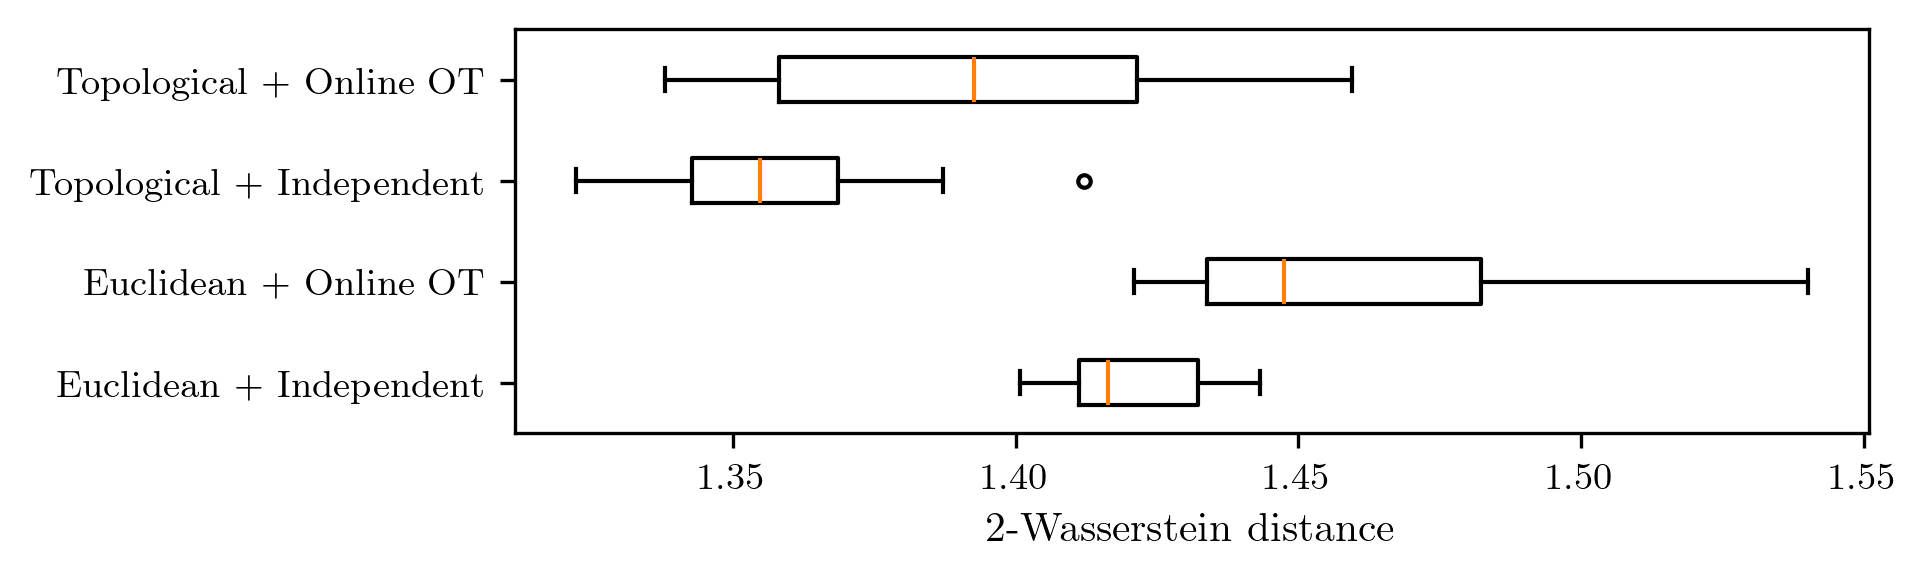

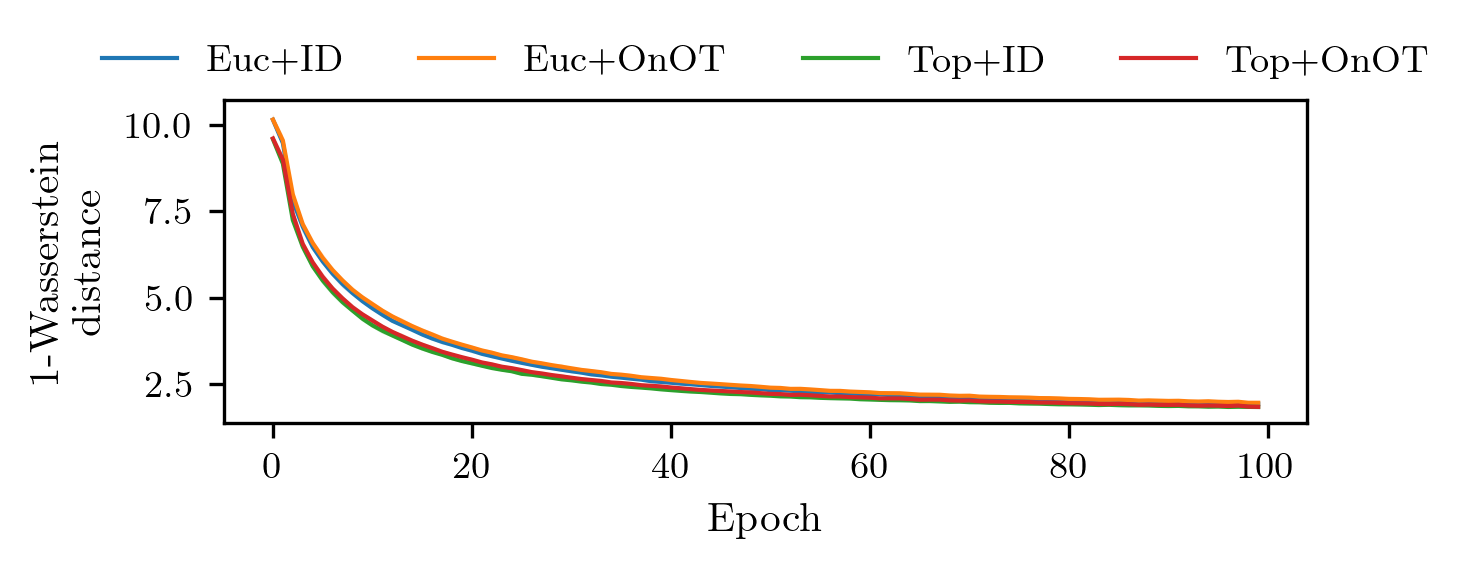

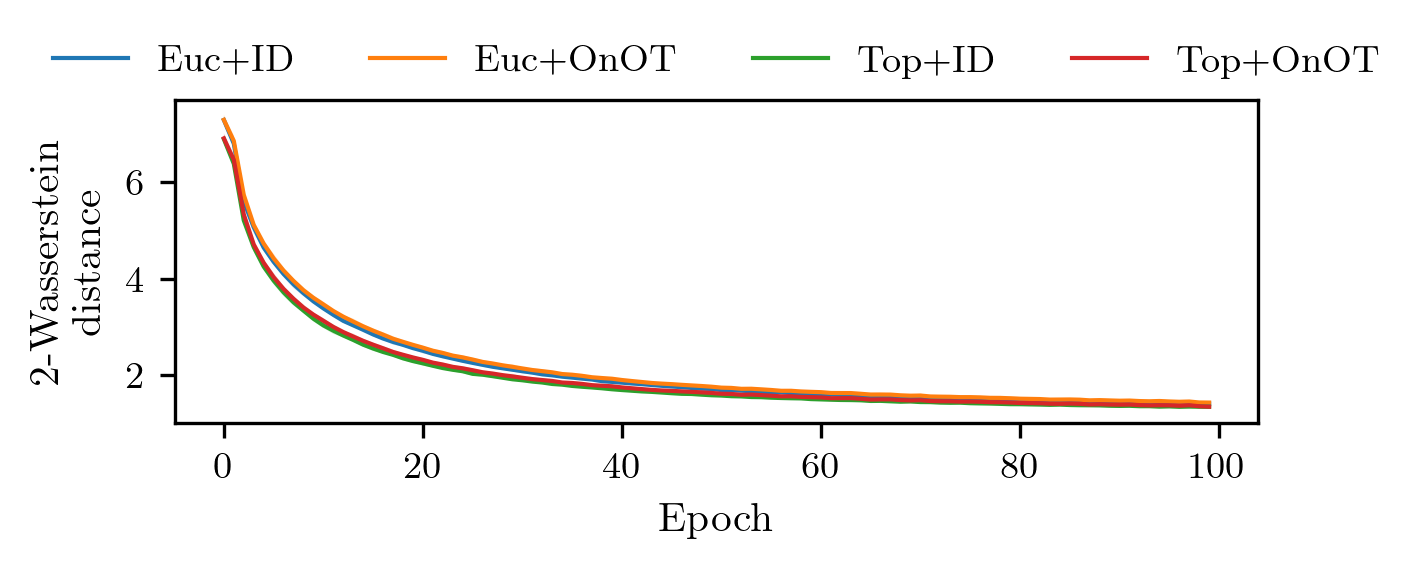

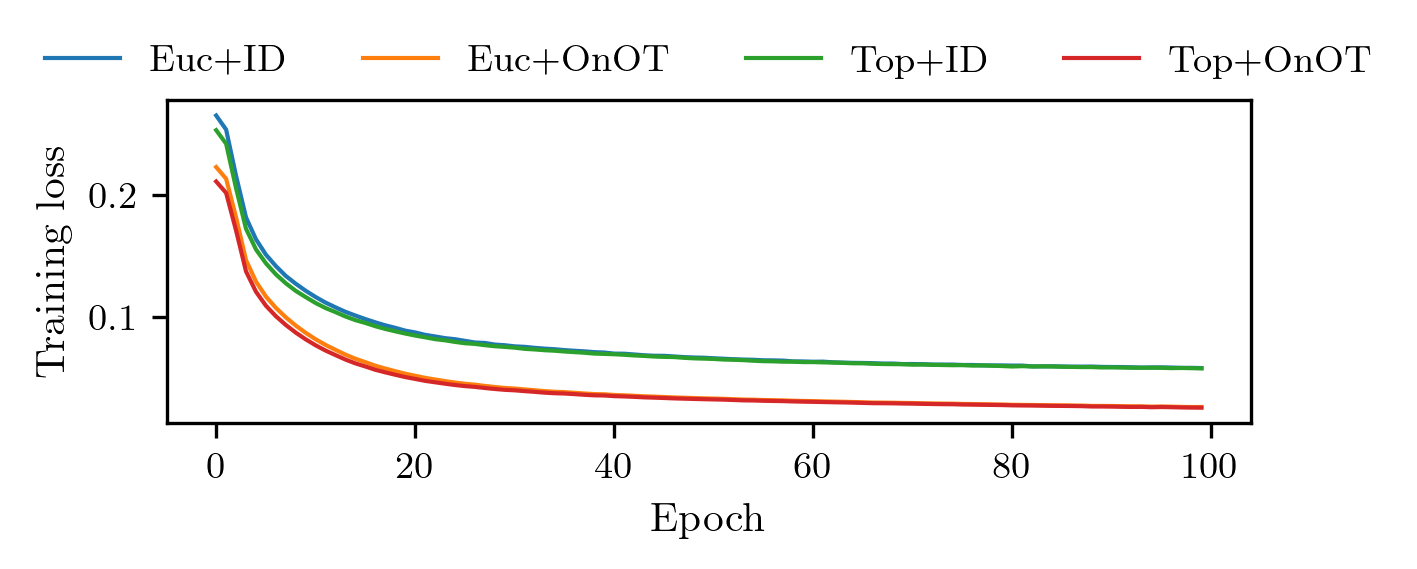

In [46]:
############################################## Fetch runs ##############################################
print("Fetching runs...")
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
experiment_name='ocean'
tags=[experiment_name]
date = datetime(year=2025, month=8, day=30)
runs = get_runs_with_tags_after_date(entity, project, tags, date)


############################################## TEST DATA ##############################################
# Load test data
print("Loading test data...")
test_metrics = [
    'test/W1', 
    'test/W2',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)
df.head()


# Plot
print("Plotting test data...")
width = PAGE_WIDTH
height = width * 0.3

fig, ax = plot_metric_boxplot(
    df, 
    'test/W1', 
    'name', 
    xlabel='1-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w1.pdf")


fig, ax = plot_metric_boxplot(
    df, 
    'test/W2', 
    'name', 
    xlabel='2-Wasserstein distance',
    width=width,
    height=height,
)
save_figure(fig, f"{experiment_name}-test_w2.pdf")



############################################## TRAINING DATA ##############################################
# Load data
print("Loading training data...")
epoch_col = "epoch"
train_metric = "train/loss"
val_metrics = ['val/W1', 'val/W2']
df = runs_to_training_history(runs, val_metrics, train_metric, epoch_col)
add_name(df)


# Plot
print("Plotting training data...")
width = PAGE_WIDTH * 0.8
height = width * 0.3

fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W1", 
    width=width, 
    height=height,
    xlabel="Epoch",
    ylabel="1-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w1.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "val/W2", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="2-Wasserstein\ndistance",
)
save_figure(fig, f"{experiment_name}-val_w2.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "train/loss", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="Training loss",
)
save_figure(fig, f"{experiment_name}-train_loss.pdf")


print("Done!")

# Experiment: single_cell

In [24]:
print("Fetching runs...")
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
experiment_name='single_cell'
tags=[experiment_name]
date = datetime(year=2025, month=8, day=31)
runs = get_runs_with_tags_after_date(entity, project, tags, date)

Fetching runs...


In [25]:
print("Loading test data...")
test_metrics = [
    'test/W1_0',
    'test/W1_1',
    'test/W1_2',
    'test/W1_3',
    'test/W1_4',
    'test/W2_0',
    'test/W2_1',
    'test/W2_2',
    'test/W2_3',
    'test/W2_4',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)

Loading test data...


/tmp/ipykernel_252297/3778568983.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


In [26]:
df

,coupling,dataset,sde,date,seed,test/W1_0,test/W1_1,test/W1_2,test/W1_3,test/W1_4,test/W2_0,test/W2_1,test/W2_2,test/W2_3,test/W2_4,name,abbrev
0,independent,single_cell,euclidean,2025-08-31T05:06:43Z,2,1.180336,0.406866,0.316685,0.195262,0.021947,1.186995,0.613721,0.566889,0.405876,0.080441,Euclidean + Independent,Euc+ID
1,independent,single_cell,euclidean,2025-08-31T05:07:06Z,3,0.720370,0.398590,0.205988,0.155584,0.021674,0.882008,0.583647,0.411339,0.336060,0.069118,Euclidean + Independent,Euc+ID
2,independent,single_cell,euclidean,2025-08-31T05:07:25Z,4,1.121465,0.426034,0.322123,0.243497,0.023391,1.148833,0.603876,0.573802,0.462143,0.063952,Euclidean + Independent,Euc+ID
3,independent,single_cell,euclidean,2025-08-31T05:07:50Z,5,1.279150,0.498064,0.248633,0.179629,0.021766,1.222743,0.699976,0.515843,0.400071,0.065566,Euclidean + Independent,Euc+ID
4,independent,single_cell,euclidean,2025-08-31T05:08:19Z,6,1.137977,0.436081,0.235882,0.212628,0.022624,1.154921,0.640039,0.475451,0.439734,0.060199,Euclidean + Independent,Euc+ID
5,independent,single_cell,euclidean,2025-08-31T05:08:52Z,7,1.184880,0.467461,0.316630,0.200455,0.023395,1.185692,0.656555,0.570537,0.411481,0.067580,Euclidean + Independent,Euc+ID
6,independent,single_cell,euclidean,2025-08-31T05:09:11Z,8,1.465700,0.353852,0.411203,0.244954,0.022849,1.360035,0.563978,0.692360,0.491755,0.073278,Euclidean + Independent,Euc+ID
7,independent,single_cell,euclidean,2025-08-31T05:09:33Z,9,1.255065,0.344150,0.386745,0.241646,0.020945,1.229276,0.545319,0.668708,0.490883,0.071476,Euclidean + Independent,Euc+ID
8,independent,single_cell,euclidean,2025-08-31T14:24:28Z,0,1.374530,0.490599,0.382747,0.263252,0.024247,1.283156,0.657008,0.656529,0.511972,0.072401,Euclidean + Independent,Euc+ID
9,independent,single_cell,euclidean,2025-08-31T14:26:23Z,1,1.186366,0.498258,0.243259,0.143082,0.020440,1.164242,0.708397,0.521849,0.339656,0.070891,Euclidean + Independent,Euc+ID


In [27]:
df.groupby(['sde', 'coupling'])['test/W1_4'].mean()

sde          coupling   
euclidean    independent    0.022328
             ot             0.019135
topological  independent    0.018490
             ot             0.019267
Name: test/W1_4, dtype: float64

In [61]:
print("Loading test data...")
test_metrics = [
    'test/W1_0',
    'test/W1_1',
    'test/W1_2',
    'test/W1_3',
    'test/W1_4',
    'test/W2_0',
    'test/W2_1',
    'test/W2_2',
    'test/W2_3',
    'test/W2_4',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)

Loading test data...


/tmp/ipykernel_252297/1033456339.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


In [63]:
df.groupby(['sde', 'coupling'])['test/W1_4'].agg(['mean', 'std'])

mean       std
sde         coupling                       
euclidean   independent  0.022328  0.001187
            ot           0.019135  0.001351
topological independent  0.018490  0.000959
            ot           0.019267  0.001171

Fetching runs...
Loading test data...


/tmp/ipykernel_252297/1033456339.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


Plotting test data...
Loading training data...


KeyError: "['_step'] not found in axis"

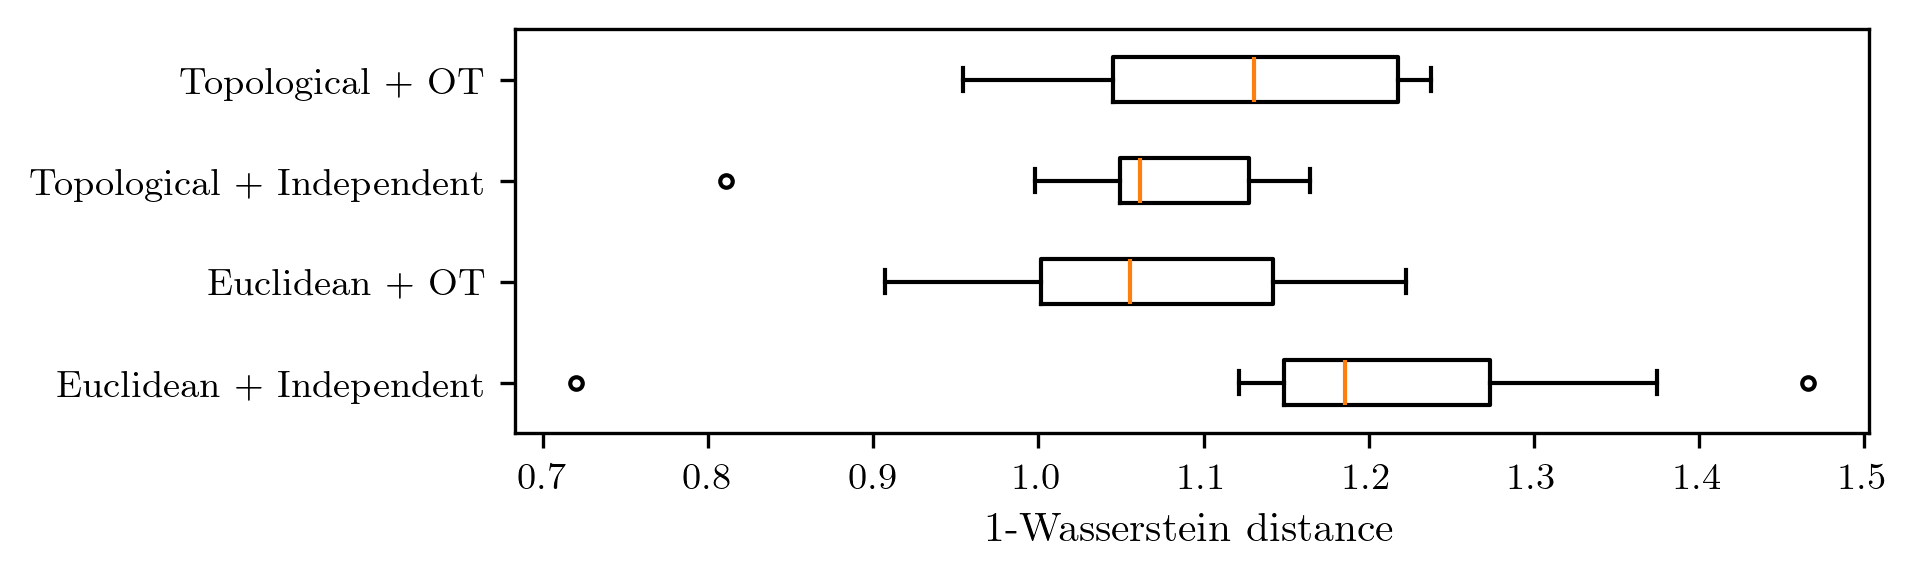

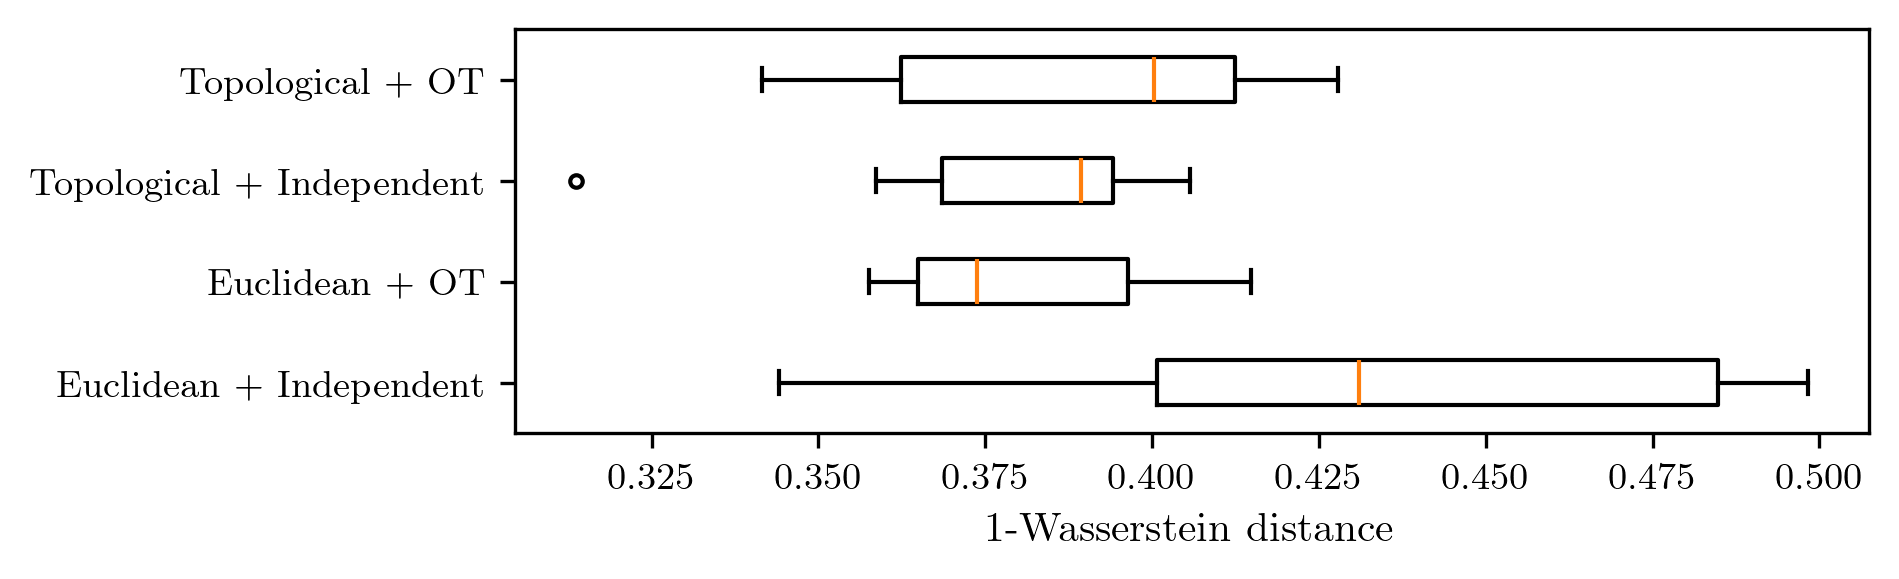

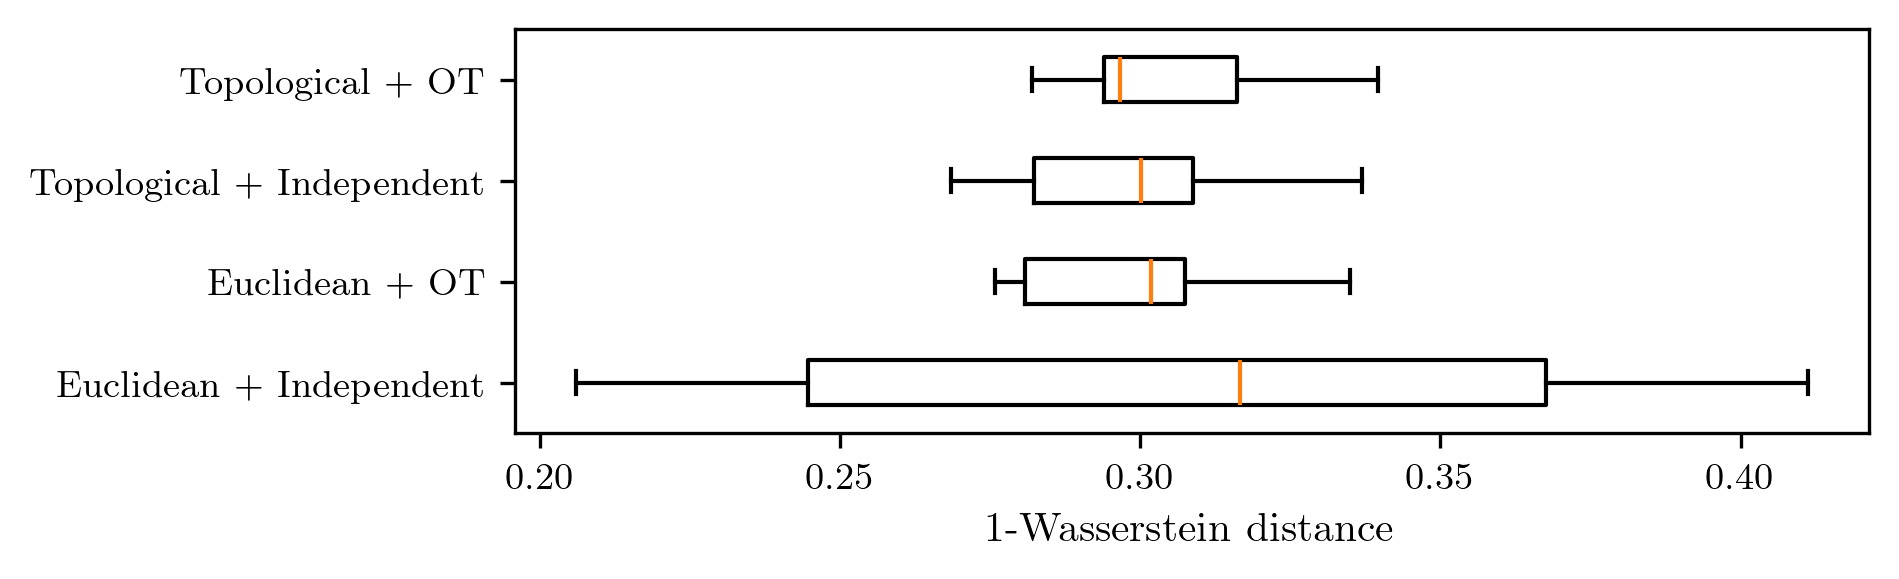

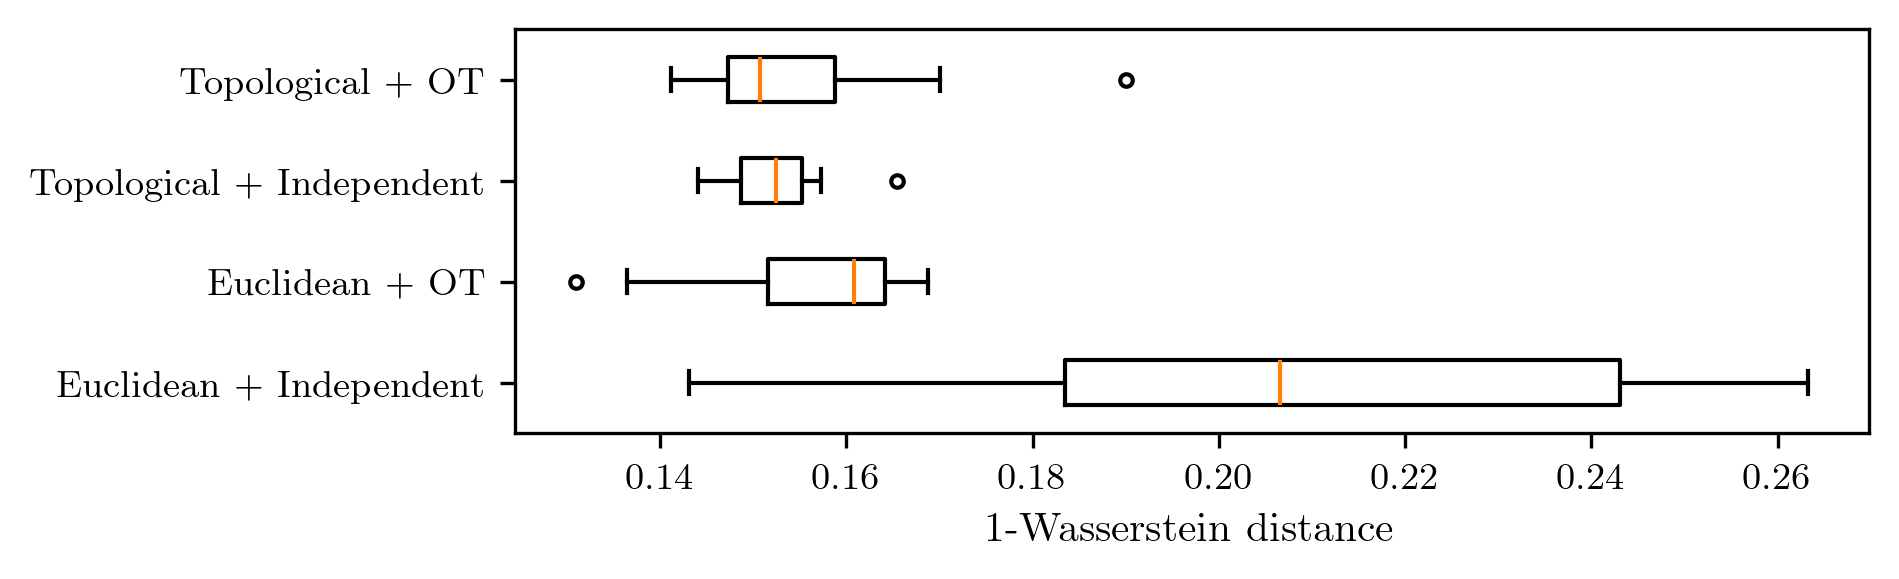

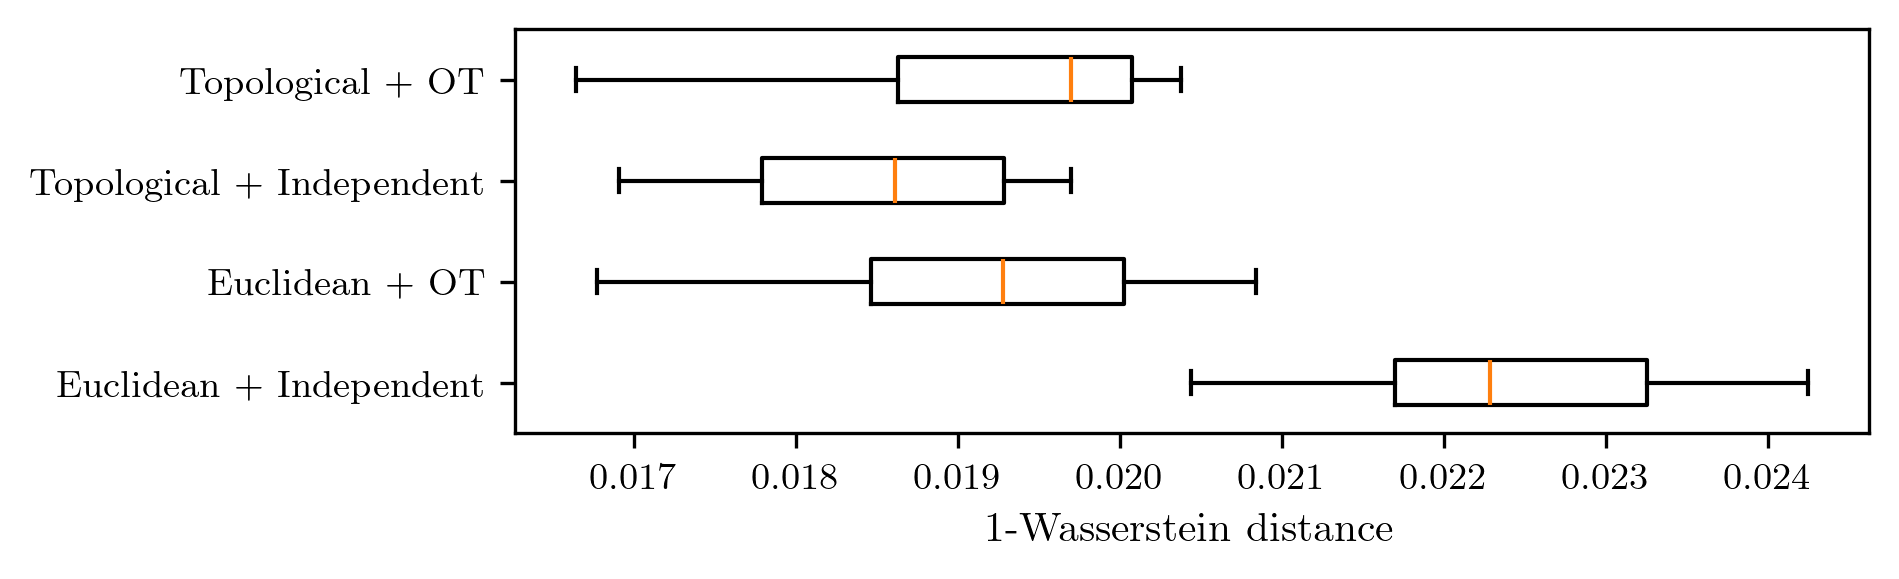

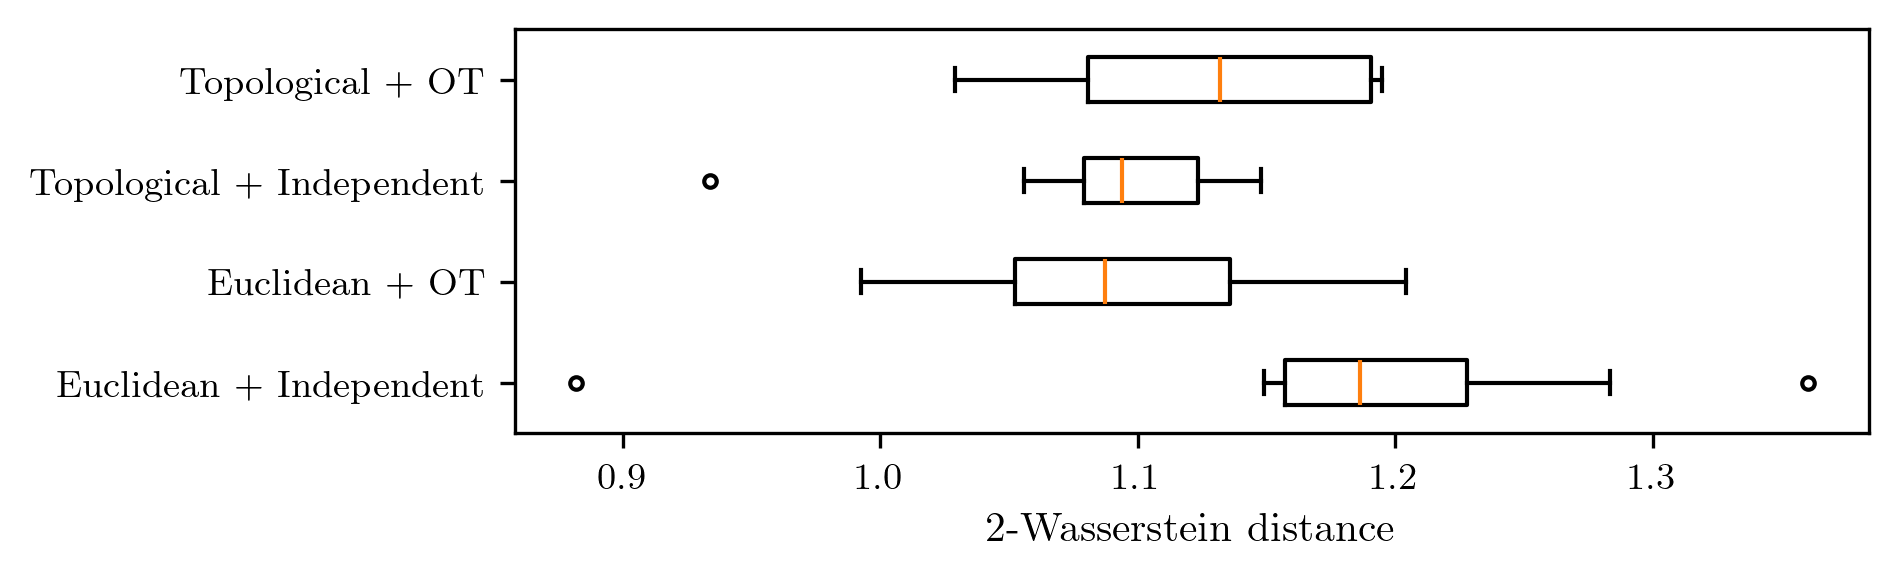

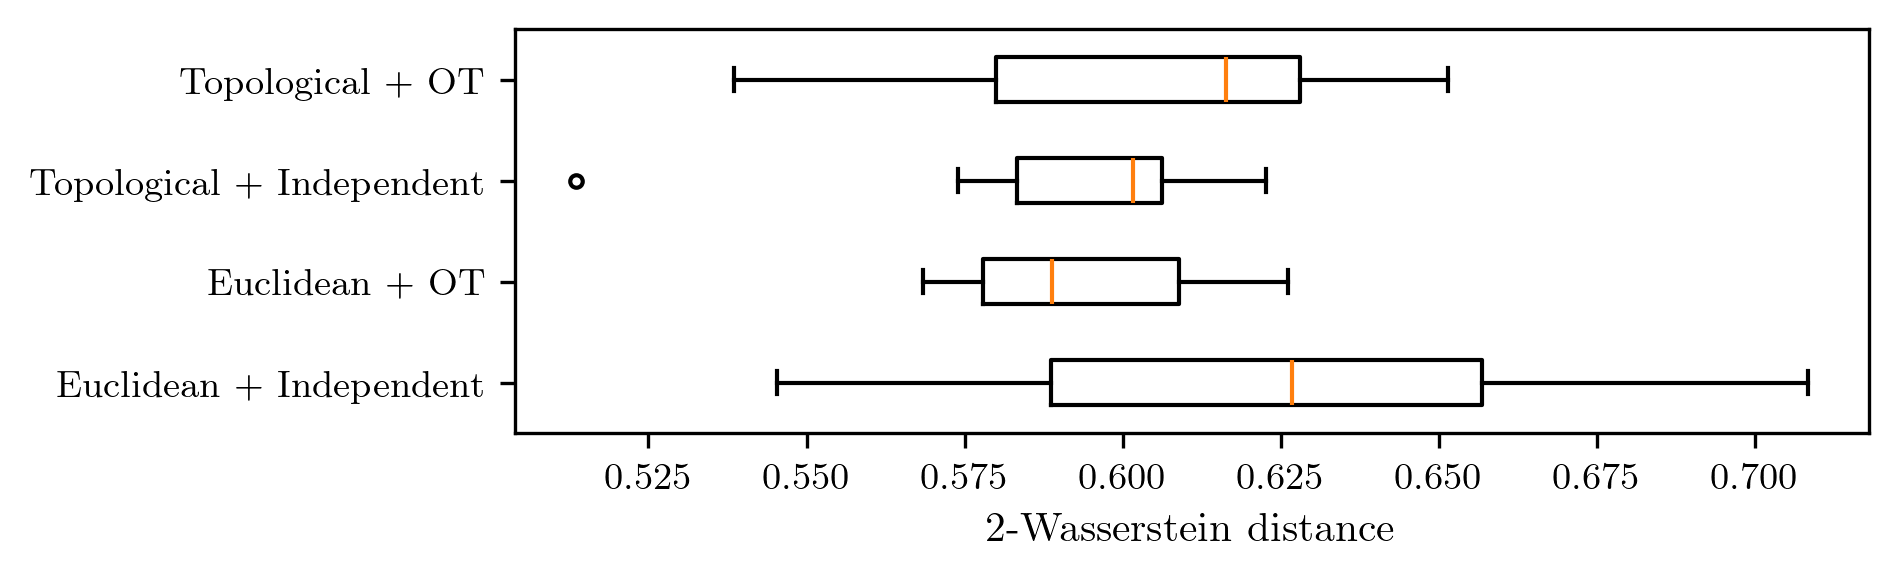

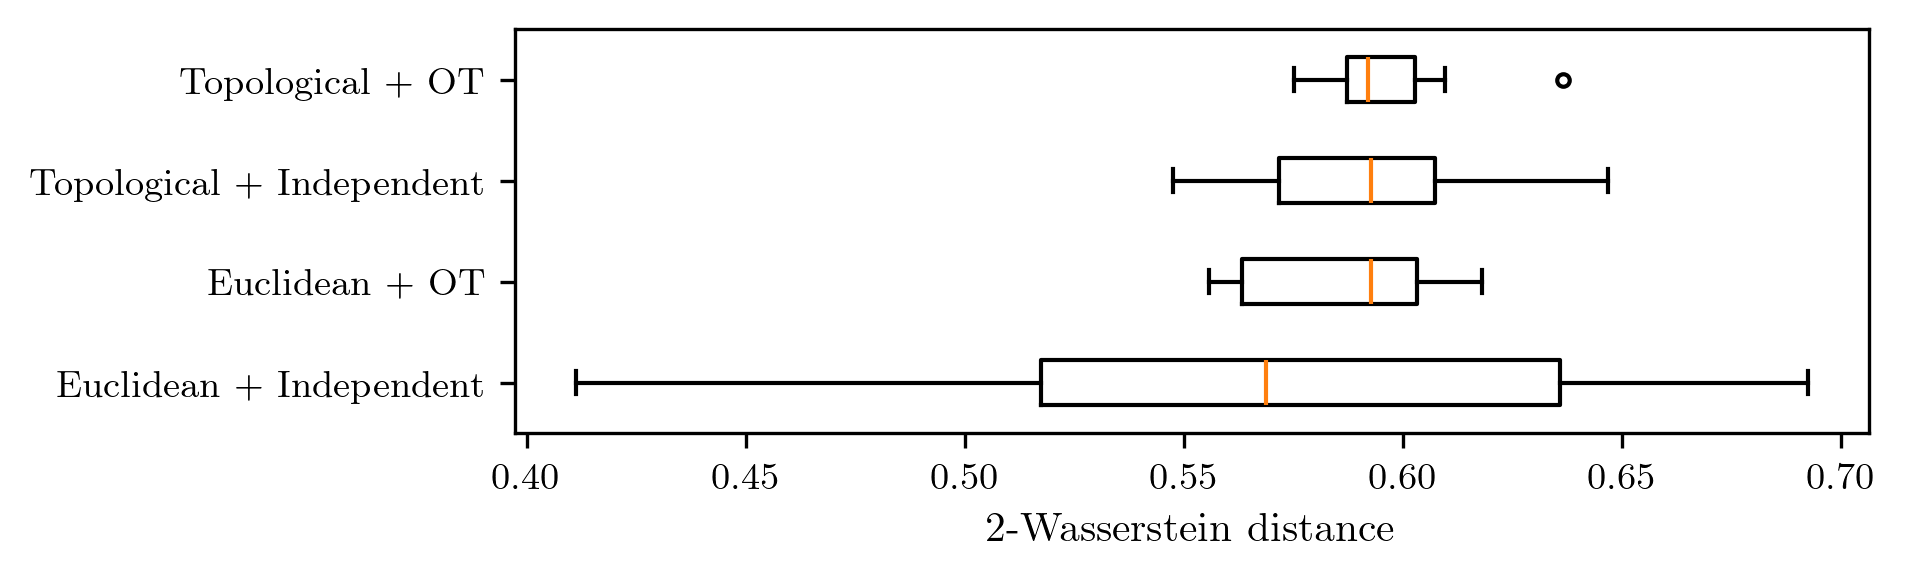

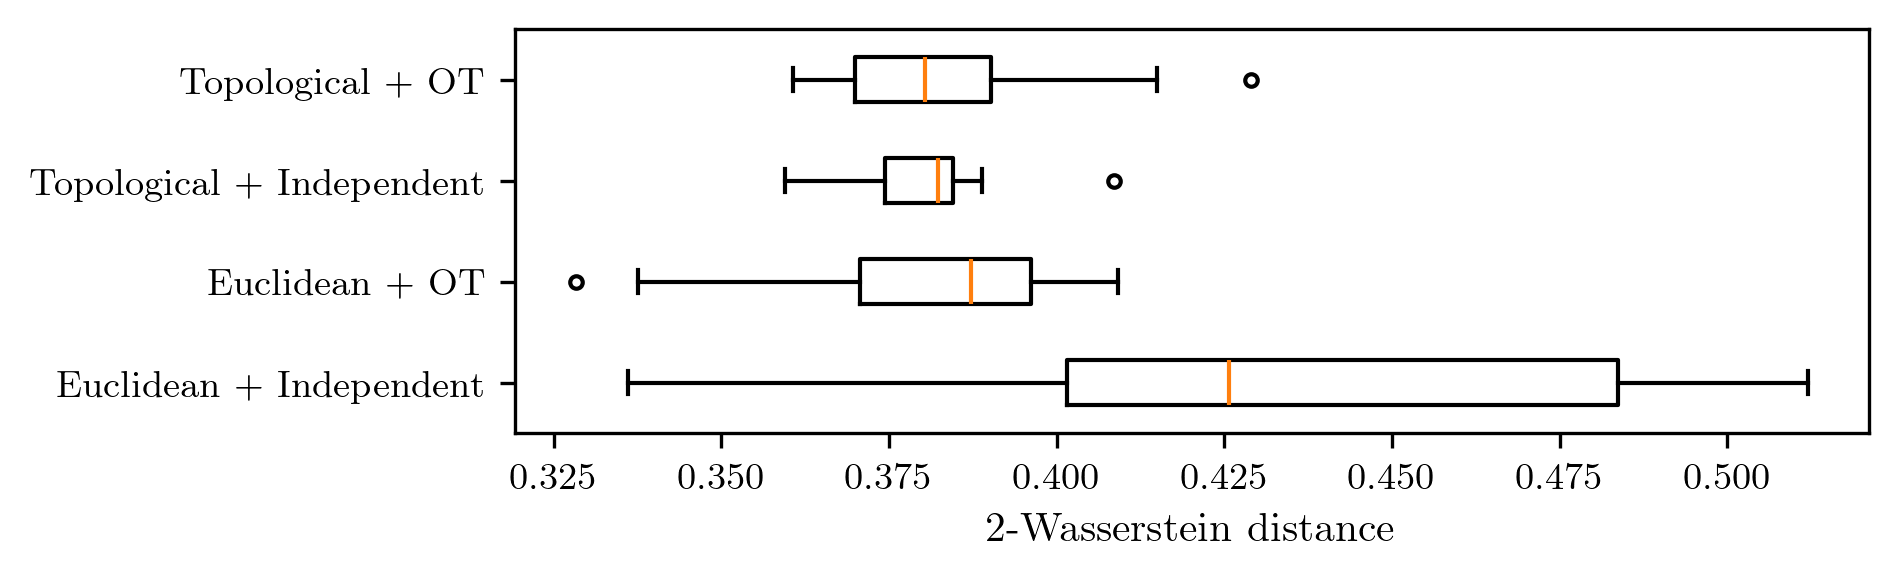

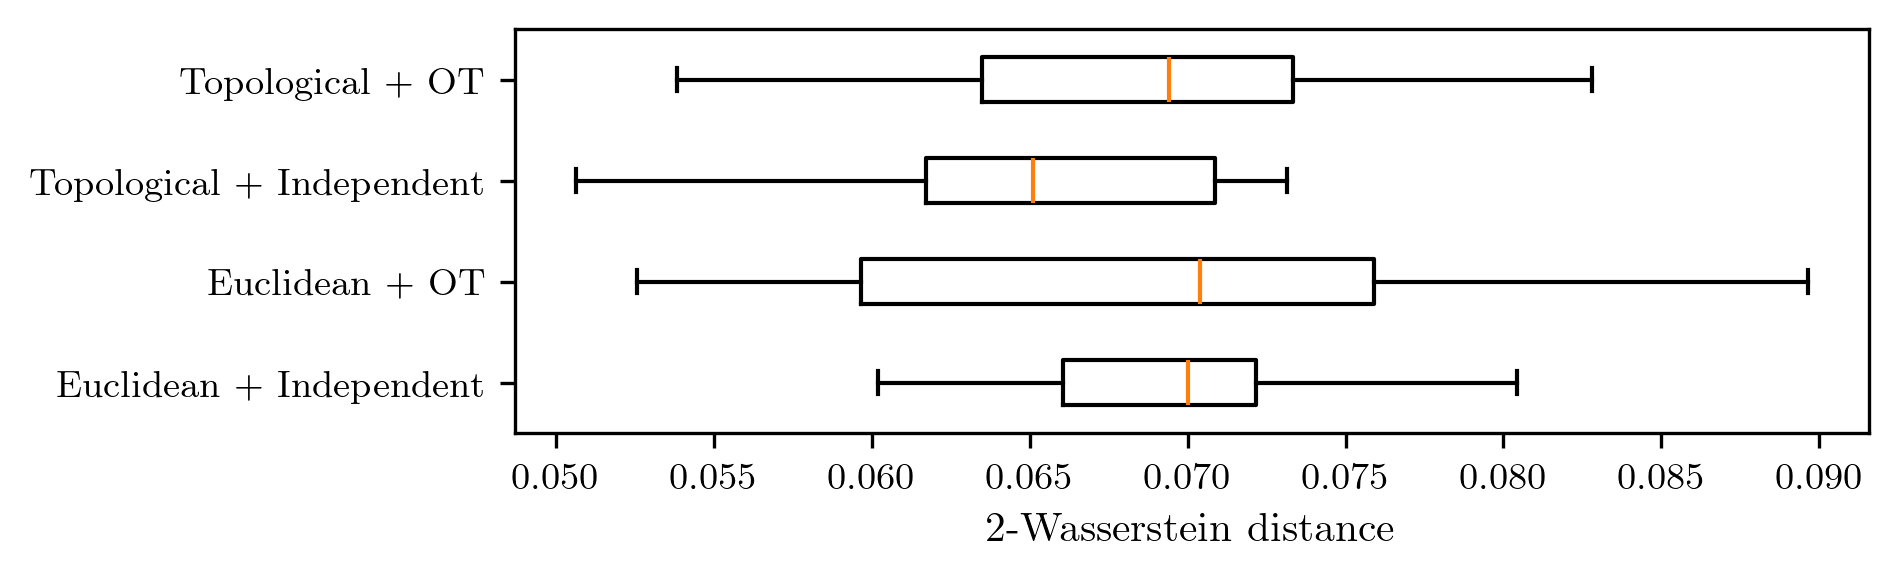

In [60]:
############################################## Fetch runs ##############################################
print("Fetching runs...")
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
experiment_name='single_cell'
tags=[experiment_name]
date = datetime(year=2025, month=8, day=31)
runs = get_runs_with_tags_after_date(entity, project, tags, date)


############################################## TEST DATA ##############################################
# Load test data
print("Loading test data...")
test_metrics = [
    'test/W1_0',
    'test/W1_1',
    'test/W1_2',
    'test/W1_3',
    'test/W1_4',
    'test/W2_0',
    'test/W2_1',
    'test/W2_2',
    'test/W2_3',
    'test/W2_4',
]
df = runs_to_metrics_df(runs, test_metrics)
df = add_name(df)
df.head()


# Plot
print("Plotting test data...")
width = PAGE_WIDTH
height = width * 0.3

for test_metric in test_metrics:
    if 'W1' in test_metric:
        xlabel = '1-Wasserstein distance'
    else:
        xlabel = '2-Wasserstein distance'
    fig, ax = plot_metric_boxplot(
        df, 
        test_metric, 
        'name', 
        xlabel=xlabel,
        width=width,
        height=height,
    )
    save_figure(fig, f"{experiment_name}-{test_metric.lower().replace('/', '_')}.pdf")



############################################## TRAINING DATA ##############################################
# Load data
print("Loading training data...")
epoch_col = "epoch"
train_metric = "train/loss"
val_metrics = [
    'val/W1_0', 
    'val/W1_1',
    'val/W1_2',
    'val/W1_3',
    'val/W1_4',
    'val/W2_0',
    'val/W2_1',
    'val/W2_2',
    'val/W2_3',
    'val/W2_4',
]
df = runs_to_training_history(runs, val_metrics, train_metric, epoch_col)
add_name(df)


# Plot
print("Plotting training data...")
width = PAGE_WIDTH * 0.8
height = width * 0.3

for val_metric in val_metrics:
    if 'W1' in val_metric:
        ylabel = '1-Wasserstein\ndistance'
    else:
        ylabel = '2-Wasserstein\ndistance'
    fig, ax = plot_epoch_metric(
        df, 
        "abbrev", 
        val_metric, 
        width=width, 
        height=height,
        xlabel="Epoch",
        ylabel=ylabel,
    )
    save_figure(fig, f"{experiment_name}-{val_metric.lower().replace('/', '_')}.pdf")


fig, ax = plot_epoch_metric(
    df, 
    "abbrev", 
    "train/loss", 
    width=width,
    height=height,
    xlabel="Epoch",
    ylabel="Training loss",
)
save_figure(fig, f"{experiment_name}-train_loss.pdf")


print("Done!")

# Summary of all experiments

In [58]:
entity="shil6408-university-of-oxford"
project="topological-flow-matching"
tags=[]
date = datetime(year=2025, month=8, day=30)
runs = get_runs_with_tags_after_date(entity, project, tags, date)
df = runs_to_metrics_df(runs, ["test/W1", "test/W2"])
df = add_name(df)

# map values
df['coupling'] = df['coupling'].replace(
    'online_ot', 'ot'
).map(coupling_to_name)
df['sde'] = df['sde'].map(sde_to_name)
df['dataset'] = df['dataset'].str.capitalize()

# map column names
df = df.rename(columns={
    'coupling': 'Coupling', 
    'sde': 'SDE',
    'W1_4': 'W1',
    'W2_4': 'W2',
})


table = make_latex_table(
    df, 
    dataset_col="dataset", 
    model_col="SDE", 
    coupling_col="Coupling", 
    metric="test/W1",
)
save_table_to_latex(table, "test_w1_table.tex")


table = make_latex_table(
    df, 
    dataset_col="dataset", 
    model_col="SDE", 
    coupling_col="Coupling", 
    metric="test/W1",
)
save_table_to_latex(table, "test_w1_table.tex")

/tmp/ipykernel_252297/1033456339.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['dataset', 'sde', 'coupling']).apply(lambda x: x.drop_duplicates(subset=['seed'], keep='last')).reset_index(drop=True)


'\\begin{tabular}{lllllll}\n\\toprule\n &  & Brain & Earthquakes & Ocean & Single_cell & Traffic \\\\\nSDE & Coupling &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{2}{*}{\\textbf{Euclidean}} & \\textbf{Independent} & 11.708 \\(\\pm\\) 0.197 & 8.366 \\(\\pm\\) 0.049 & 1.954 \\(\\pm\\) 0.020 & \\textbf{nan \\(\\pm\\) nan} & 1.722 \\(\\pm\\) 0.108 \\\\\n\\textbf{} & \\textbf{OT} & 11.302 \\(\\pm\\) 0.109 & 8.252 \\(\\pm\\) 0.058 & 2.004 \\(\\pm\\) 0.054 & nan \\(\\pm\\) nan & 1.593 \\(\\pm\\) 0.112 \\\\\n\\cline{1-7}\n\\multirow[t]{2}{*}{\\textbf{Topological}} & \\textbf{Independent} & 6.331 \\(\\pm\\) 0.186 & \\textbf{4.932 \\(\\pm\\) 0.623} & \\textbf{1.865 \\(\\pm\\) 0.036} & nan \\(\\pm\\) nan & \\textbf{1.271 \\(\\pm\\) 0.005} \\\\\n\\textbf{} & \\textbf{OT} & \\textbf{5.856 \\(\\pm\\) 0.115} & 5.533 \\(\\pm\\) 0.184 & 1.907 \\(\\pm\\) 0.059 & nan \\(\\pm\\) nan & 1.272 \\(\\pm\\) 0.004 \\\\\n\\cline{1-7}\n\\bottomrule\n\\end{tabular}\n'

In [59]:
table

Brain  \
SDE         Coupling                                    
Euclidean   Independent          11.708 \(\pm\) 0.197   
            OT                   11.302 \(\pm\) 0.109   
Topological Independent           6.331 \(\pm\) 0.186   
            OT           \textbf{5.856 \(\pm\) 0.115}   

                                          Earthquakes  \
SDE         Coupling                                    
Euclidean   Independent           8.366 \(\pm\) 0.049   
            OT                    8.252 \(\pm\) 0.058   
Topological Independent  \textbf{4.932 \(\pm\) 0.623}   
            OT                    5.533 \(\pm\) 0.184   

                                                Ocean  \
SDE         Coupling                                    
Euclidean   Independent           1.954 \(\pm\) 0.020   
            OT                    2.004 \(\pm\) 0.054   
Topological Independent  \textbf{1.865 \(\pm\) 0.036}   
            OT                    1.907 \(\pm\) 0.059   

                                      Single_cell  \
SDE         Coupling                                
Euclidean   Independent  \textbf{nan \(\pm\) nan}   
            OT                    nan \(\pm\) nan   
Topological Independent           nan \(\pm\) nan   
            OT                    nan \(\pm\) nan   

                                              Traffic  
SDE         Coupling                                   
Euclidean   Independent           1.722 \(\pm\) 0.108  
            OT                    1.593 \(\pm\) 0.112  
Topological Independent  \textbf{1.271 \(\pm\) 0.005}  
            OT                    1.272 \(\pm\) 0.004